# Machine Learning in Finance: Final Project
## Machine Learning in NBA Over/Under Betting
### Business 35137 | Chicago Booth

**Research Question:** Can machine learning models beat the Vegas total when predicting NBA game points, and under what conditions do selective bets outperform a flat-bet strategy?

**Plain-language summary:** A Vegas total is the bookmaker's estimate of combined points in a game. If the final score is higher than the line, the **Over** wins; if lower, the **Under** wins. We build models from past games, compare their predictions to the line, and ask whether the model can win often enough to overcome the betting fee (the "vig").

**Why this is hard:** The Vegas line already reflects expert knowledge, injuries, and public money. To beat it, the model must find a small, repeatable pattern the market misses.

**What we do in this notebook:**
- Build lagged, within-season team features from box scores.
- Train several models on 2008-2024 and test on 2024-2025.
- Evaluate accuracy, error, and return on investment (ROI).
- Test selective betting and confidence-weighted bet sizing.

**Data:** 23,118 NBA games (2008-2025) with betting lines and box score statistics.

**How to read this notebook (quick guide)**
- The goal is to evaluate prediction quality first, then show how that translates into betting decisions.
- Parts 1-4 build data, features, and models; Parts 5-8 test selective betting and sizing.
- When you re-run, all tables and plots update; the text is written to match outputs, not hard-coded numbers.

**Table of contents**
1. Setup and imports
2. Data
3. Feature engineering
4. Model training and evaluation
5. Confidence threshold analysis
6. Statistical significance
7. Recap and path to profit
8. Confidence-weighted betting
9. Alternative data and advanced models (plan)
10. Real-world implementation constraints (plan)
11. 2025-26 season / Bulls tracker (plan)


---
## Part 1: Setup and Imports

In [240]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import warnings
import time
import requests
from math import erf, sqrt
warnings.filterwarnings('ignore')

from sklearn.linear_model import Ridge, Lasso, ElasticNet, LinearRegression
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.kernel_approximation import RBFSampler
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from nba_api.stats.endpoints import leaguegamelog

# Consistent plot style
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'axes.grid': True,
    'grid.alpha': 0.3,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 11,
    'figure.titlesize': 15,
})

COLORS = {
    'primary': '#1F77B4',
    'secondary': '#FF7F0E',
    'profit': '#2CA02C',
    'loss': '#D62728',
    'neutral': '#4D4D4D',
    'highlight': '#17BECF',
    'breakeven': '#D62728',
    'vegas': '#4D4D4D',
}

MODEL_COLORS = {
    'OLS': '#9467BD',
    'Ridge': '#1F77B4',
    'Lasso': '#D62728',
    'Elastic Net': '#8C564B',
    'Gradient Boosting': '#2CA02C',
    'PCR': '#17BECF',
    'RBF+Ridge': '#FF7F0E',
    'Vegas (benchmark)': '#4D4D4D',
}

os.makedirs('Images', exist_ok=True)
print("Setup complete.")

Setup complete.


---
## Part 2: Data

We combine two sources and then fill gaps:
1. **Betting data (2008-2025):** Vegas totals, spreads, and final scores (23,118 games).
2. **NBA game data (2008-2023):** Box score statistics (shots, rebounds, turnovers, etc.).

**What a Vegas line is:** The total is the bookmaker's predicted combined points for a game. The spread is the predicted point difference between teams. We treat these as the market's best public forecast.

**Why we merge sources:** Betting data has the line and final scores, but not detailed box scores. Box score data has the team stats we need to build features but is missing some seasons. We merge them to get both the line and the predictors in the same row.

To fix missing seasons (notably 2012-2013), we pull team game logs from the NBA Stats API and merge them into the game dataset. We also use the API for 2024-2025 in the same format.

**Why coverage differs in 2020 and after:** The NBA season was shortened and rescheduled due to COVID. Betting data records every listed game with final scores, while the box-score dataset can lose rows after team-code standardization and duplicate removal. The two sources are curated differently, so perfect alignment is not guaranteed.

**COVID sanity check:** We only use games with final scores, so canceled or unplayed games are excluded from both the modeling set and the rolling stats.

**Line note:** The betting file provides a single total and spread per game (no explicit open/close fields). We treat it as the market line in the dataset; separating opening vs closing would require a different data source.

In [241]:
# Team abbreviation mappings
TEAM_MAP_BETTING = {'gs': 'GSW', 'no': 'NOP', 'ny': 'NYK', 'sa': 'SAS', 'utah': 'UTA', 'wsh': 'WAS'}
TEAM_MAP_HISTORICAL = {'NJN': 'BKN', 'NOH': 'NOP', 'NOK': 'NOP', 'NOJ': 'NOP',
                        'SEA': 'OKC', 'CHN': 'CHA', 'CHH': 'CHA', 'VAN': 'MEM'}

def standardize_team(abbr, source='betting'):
    if source == 'betting':
        return TEAM_MAP_BETTING.get(abbr, abbr.upper())
    if source == 'historical':
        return TEAM_MAP_HISTORICAL.get(abbr, abbr)
    return abbr

def season_end_year(dates):
    return dates.dt.year + (dates.dt.month >= 7)

def make_season_label(season_end):
    if isinstance(season_end, (int, np.integer)):
        return f"{season_end - 1}/{str(season_end)[-2:]}"
    s = season_end.astype(int)
    return (s - 1).astype(str) + '/' + s.astype(str).str[-2:]

def load_api_game_data(seasons, cache_dir='Data/Game Data'):
    all_rows = []
    for season in seasons:
        cache_path = os.path.join(cache_dir, f"game_{season.replace('-', '_')}_api.csv")
        if os.path.exists(cache_path):
            season_df = pd.read_csv(cache_path)
            all_rows.append(season_df)
            continue
        dfs = []
        for stype in ['Regular Season', 'Playoffs']:
            log = leaguegamelog.LeagueGameLog(season=season, season_type_all_star=stype)
            df = log.get_data_frames()[0]
            dfs.append(df)
            time.sleep(1.0)
        season_df = pd.concat(dfs, ignore_index=True)
        season_df.to_csv(cache_path, index=False)
        all_rows.append(season_df)
    return pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()

def api_team_logs_to_games(api_df):
    if api_df.empty:
        return pd.DataFrame()
    api_df = api_df.copy()
    api_df['GAME_DATE'] = pd.to_datetime(api_df['GAME_DATE'], format='mixed', errors='coerce')
    api_df = api_df.dropna(subset=['GAME_DATE'])
    api_df['is_home'] = api_df['MATCHUP'].str.contains(r'vs\.').astype(int)
    home_api = api_df[api_df['is_home'] == 1].copy()
    away_api = api_df[api_df['is_home'] == 0].copy()
    merged = home_api.merge(away_api, on='GAME_ID', suffixes=('_home', '_away'))

    api_map = {'PTS': 'pts', 'FGM': 'fgm', 'FGA': 'fga', 'FG_PCT': 'fg_pct',
               'FG3M': 'fg3m', 'FG3A': 'fg3a', 'FG3_PCT': 'fg3_pct',
               'FTM': 'ftm', 'FTA': 'fta', 'FT_PCT': 'ft_pct',
               'OREB': 'oreb', 'DREB': 'dreb', 'REB': 'reb',
               'AST': 'ast', 'STL': 'stl', 'BLK': 'blk', 'TOV': 'tov', 'PF': 'pf'}
    api_rename = {'GAME_ID': 'game_id', 'GAME_DATE_home': 'game_date',
                  'TEAM_ABBREVIATION_home': 'home_team', 'TEAM_ABBREVIATION_away': 'away_team'}
    for ac, lc in api_map.items():
        api_rename[f'{ac}_home'] = f'{lc}_home'
        api_rename[f'{ac}_away'] = f'{lc}_away'
    return merged[list(api_rename.keys())].rename(columns=api_rename)

def load_game_data(api_seasons=None):
    """Load and merge box score data: game.csv (2008-2023) + API data (2012-13 + 2024-2025)."""
    # Historical
    game_hist = pd.read_csv('Data/Game Data/game.csv')
    game_hist['game_date'] = pd.to_datetime(game_hist['game_date'])
    game_hist = game_hist[
        (game_hist['season_id'].astype(str).str[1:].astype(int) >= 2007) &
        (game_hist['season_type'].isin(['Regular Season', 'Playoffs']))
    ].copy()
    for col in ['team_abbreviation_home', 'team_abbreviation_away']:
        game_hist[col] = game_hist[col].map(lambda x: standardize_team(x, 'historical'))

    stats = ['pts', 'fgm', 'fga', 'fg_pct', 'fg3m', 'fg3a', 'fg3_pct',
             'ftm', 'fta', 'ft_pct', 'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov', 'pf']
    rename = {'game_id': 'game_id', 'game_date': 'game_date',
              'team_abbreviation_home': 'home_team', 'team_abbreviation_away': 'away_team'}
    for s in stats:
        rename[f'{s}_home'] = f'{s}_home'
        rename[f'{s}_away'] = f'{s}_away'
    game_hist = game_hist[list(rename.keys())].rename(columns=rename)

    # API data (CSV for 2024-2025 + fetch for 2012-2013)
    api_csv = pd.read_csv('Data/Game Data/game_2024_2025.csv')
    if api_seasons is None:
        api_seasons = ['2012-13']
    api_extra = load_api_game_data(api_seasons) if api_seasons else pd.DataFrame()
    api_all = pd.concat([api_csv, api_extra], ignore_index=True)
    api_games = api_team_logs_to_games(api_all)

    all_games = pd.concat([game_hist, api_games], ignore_index=True)
    all_games['game_key'] = all_games['game_date'].dt.strftime('%Y%m%d') + '_' + all_games['home_team'] + '_' + all_games['away_team']
    all_games = all_games.sort_values('game_date').drop_duplicates('game_key').drop(columns=['game_key'])
    all_games['season_end'] = season_end_year(all_games['game_date'])
    all_games['season_label'] = make_season_label(all_games['season_end'])
    all_games['season'] = all_games['season_end']
    print(f"Game data: {len(all_games):,} games ({len(game_hist):,} historical + {len(api_games):,} API)")
    return all_games

def load_betting_data(filepath='Data/Betting Data/nba_2008-2025.csv'):
    df = pd.read_csv(filepath)
    df['date'] = pd.to_datetime(df['date'])
    df = df.sort_values('date').reset_index(drop=True)
    df['actual_total'] = df['score_away'] + df['score_home']
    df['over_hit'] = (df['actual_total'] > df['total']).astype(int)
    df['season_end'] = season_end_year(df['date'])
    df['season_label'] = make_season_label(df['season_end'])
    df['season'] = df['season_end']
    print(f"Betting data: {len(df):,} games ({df['date'].min().date()} to {df['date'].max().date()})")
    return df

def compute_rolling_features(game_data, windows=[5, 10]):
    """Compute lagged rolling stats within each season (no cross-season leakage)."""
    if 'season_end' not in game_data.columns:
        game_data = game_data.copy()
        game_data['season_end'] = season_end_year(game_data['game_date'])

    home = game_data[['game_date', 'season_end', 'home_team', 'pts_home', 'pts_away',
        'fg_pct_home', 'fg3_pct_home', 'ft_pct_home',
        'oreb_home', 'dreb_home', 'reb_home', 'ast_home', 'stl_home', 'blk_home', 'tov_home']].copy()
    home.columns = ['game_date', 'season_end', 'team', 'pts_scored', 'pts_allowed',
        'fg_pct', 'fg3_pct', 'ft_pct', 'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov']
    home['is_home'] = 1
    home['total'] = home['pts_scored'] + home['pts_allowed']
    home['win'] = (home['pts_scored'] > home['pts_allowed']).astype(int)

    away = game_data[['game_date', 'season_end', 'away_team', 'pts_away', 'pts_home',
        'fg_pct_away', 'fg3_pct_away', 'ft_pct_away',
        'oreb_away', 'dreb_away', 'reb_away', 'ast_away', 'stl_away', 'blk_away', 'tov_away']].copy()
    away.columns = ['game_date', 'season_end', 'team', 'pts_scored', 'pts_allowed',
        'fg_pct', 'fg3_pct', 'ft_pct', 'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov']
    away['is_home'] = 0
    away['total'] = away['pts_scored'] + away['pts_allowed']
    away['win'] = (away['pts_scored'] > away['pts_allowed']).astype(int)

    all_tg = pd.concat([home, away]).sort_values('game_date')
    stat_cols = ['pts_scored', 'pts_allowed', 'fg_pct', 'fg3_pct', 'ft_pct',
                 'oreb', 'dreb', 'reb', 'ast', 'stl', 'blk', 'tov', 'total', 'win']

    results = []
    for (team, season_end), tg in all_tg.groupby(['team', 'season_end']):
        tg = tg.sort_values('game_date').copy()
        tg['days_rest'] = tg['game_date'].diff().dt.days
        tg['back_to_back'] = (tg['days_rest'] == 1).astype(int)
        for w in windows:
            for col in stat_cols:
                tg[f'{col}_L{w}'] = tg[col].shift(1).rolling(w, min_periods=1).mean()
            tg[f'days_rest_L{w}'] = tg['days_rest'].shift(1).rolling(w, min_periods=1).mean()
        results.append(tg)
    return pd.concat(results, ignore_index=True)

def create_feature_matrix(betting_df, game_data, windows=[5, 10]):
    """Join betting data with rolling game stats -> ~80 features."""
    print("Computing rolling features...")
    rolling = compute_rolling_features(game_data, windows)
    roll_cols = [c for c in rolling.columns if '_L' in c]

    df = betting_df.copy()
    df['home_std'] = df['home'].map(lambda x: standardize_team(x, 'betting'))
    df['away_std'] = df['away'].map(lambda x: standardize_team(x, 'betting'))
    features = df[['date', 'home', 'away', 'home_std', 'away_std',
                    'total', 'spread', 'actual_total', 'over_hit', 'season_end', 'season_label']].copy()
    features['season'] = features['season_end']

    home_roll = rolling[rolling['is_home'] == 1][['game_date', 'team'] + roll_cols].copy()
    home_roll.columns = ['date', 'home_std'] + ['H_' + c for c in roll_cols]
    features = features.merge(home_roll, on=['date', 'home_std'], how='left')

    away_roll = rolling[rolling['is_home'] == 0][['game_date', 'team'] + roll_cols].copy()
    away_roll.columns = ['date', 'away_std'] + ['A_' + c for c in roll_cols]
    features = features.merge(away_roll, on=['date', 'away_std'], how='left')

    for w in windows:
        features[f'combined_pts_L{w}'] = features[f'H_pts_scored_L{w}'] + features[f'A_pts_scored_L{w}']
        features[f'combined_allowed_L{w}'] = features[f'H_pts_allowed_L{w}'] + features[f'A_pts_allowed_L{w}']
        features[f'expected_total_L{w}'] = (
            features[f'H_pts_scored_L{w}'] + features[f'A_pts_scored_L{w}'] +
            features[f'H_pts_allowed_L{w}'] + features[f'A_pts_allowed_L{w}']) / 2
        features[f'combined_reb_L{w}'] = features[f'H_reb_L{w}'] + features[f'A_reb_L{w}']
        features[f'combined_ast_L{w}'] = features[f'H_ast_L{w}'] + features[f'A_ast_L{w}']
        features[f'combined_tov_L{w}'] = features[f'H_tov_L{w}'] + features[f'A_tov_L{w}']
        features[f'combined_fg_pct_L{w}'] = (features[f'H_fg_pct_L{w}'] + features[f'A_fg_pct_L{w}']) / 2
        features[f'combined_fg3_pct_L{w}'] = (features[f'H_fg3_pct_L{w}'] + features[f'A_fg3_pct_L{w}']) / 2
        features[f'rest_diff_L{w}'] = features[f'H_days_rest_L{w}'] - features[f'A_days_rest_L{w}']

    features['vegas_total'] = features['total']
    features['vegas_spread'] = features['spread']
    features = features.drop(columns=['home_std', 'away_std'], errors='ignore')

    n_before = len(features)
    features = features.dropna()
    print(f"Feature matrix: {len(features):,} games (dropped {n_before - len(features):,} with insufficient history)")
    return features

def get_feature_columns(df):
    exclude = {'date', 'home', 'away', 'total', 'actual_total', 'over_hit', 'season', 'season_end', 'season_label', 'spread',
               'score_home', 'score_away', 'regular', 'playoffs',
               'whos_favored', 'moneyline_away', 'moneyline_home',
               'h2_spread', 'h2_total', 'id_spread', 'id_total',
               'q1_away', 'q2_away', 'q3_away', 'q4_away', 'ot_away',
               'q1_home', 'q2_home', 'q3_home', 'q4_home', 'ot_home'}
    return [c for c in df.columns if c not in exclude]

print("=" * 70)
print("DATA PIPELINE")
print("=" * 70)
game_data = load_game_data()
betting_data = load_betting_data()

DATA PIPELINE
Game data: 23,081 games (19,230 historical + 3,936 API)
Betting data: 23,118 games (2007-10-30 to 2025-06-22)


 season_end  betting_games  game_rows
       2016           1316       1316
       2017           1309       1309
       2018           1312       1312
       2019           1312       1312
       2020            971        971
       2021           1335       1328
       2022           1331       1325
       2023           1320       1314
       2024           1319       1312
       2025           1321       1309


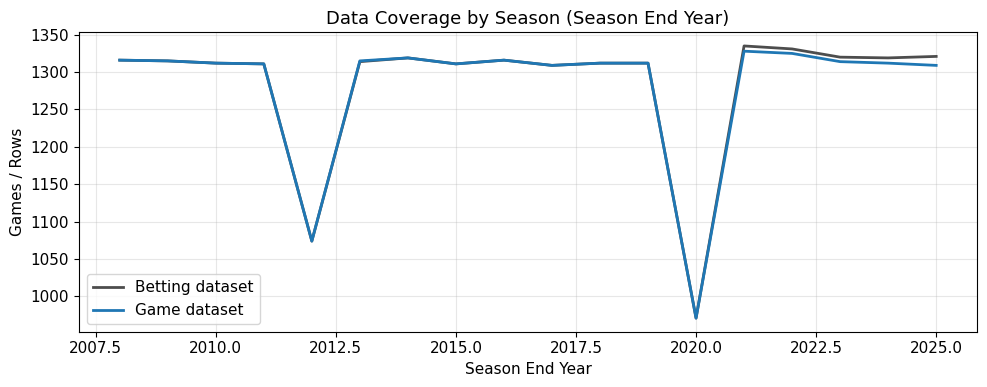

In [242]:
# Data coverage by season (season_end = year season ends)
betting_counts = betting_data.groupby('season_end').size().reset_index(name='betting_games')
game_counts = game_data.groupby('season_end').size().reset_index(name='game_rows')

cov = betting_counts.merge(game_counts, on='season_end', how='left')
print(cov.tail(10).to_string(index=False))

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(cov['season_end'], cov['betting_games'], label='Betting dataset', color=COLORS['vegas'], lw=2)
ax.plot(cov['season_end'], cov['game_rows'], label='Game dataset', color=COLORS['primary'], lw=2)
ax.set_title('Data Coverage by Season (Season End Year)')
ax.set_xlabel('Season End Year'); ax.set_ylabel('Games / Rows')
ax.legend()
plt.tight_layout()
plt.savefig('Images/data_coverage.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations:**
- The 2012-2013 drop is now largely repaired after pulling game logs from the NBA Stats API.
- 2020 shows a visible dip because the season itself was shorter; any residual mismatch reflects source-specific coverage and merge rules.
- Post-2020 coverage is close but not identical (for example, 2021-2025 differ by a handful of rows), reflecting curation and duplicate removal.
- We only use games with final scores, so canceled or unplayed COVID-era games are not included in the modeling set.

**Why this matters:** If a season has fewer box-score rows than betting rows, we lose some games in the feature set. That reduces sample size and can slightly change model estimates.

**Next step:** Build rolling, lagged team features to avoid lookahead bias.

---
## Part 3: Feature Engineering

We create lagged rolling predictors (L5/L10) from team box score data to avoid lookahead bias.

**What "lagged" means:** For a game on date $t$, we only use information from games before $t$. We never use the current game's stats to predict itself.

**What a rolling average is:** A rolling average smooths recent performance by averaging the last $w$ games (here $w=5$ or $10$). This captures short-term form (L5) and medium-term form (L10).

**No cross-season leakage:** All rolling windows are within-season only. Early-season games do not borrow from last season.

Feature groups:
- **Scoring and defense:** points scored/allowed, expected total
- **Efficiency:** FG%, 3P%, FT%
- **Possession proxies:** rebounds, turnovers, assists
- **Scheduling context:** rest days and back-to-backs

We keep the Vegas total and spread as explicit features so we can measure how much incremental signal the box-score history adds beyond the market line.

**How a single game prediction is built (plain workflow)**
1. Identify the two teams playing and the game date.
2. For each team, compute rolling L5/L10 averages from prior games only in the same season (no lookahead).
3. Join the home and away rolling features to the betting row for that exact date and matchup.
4. Combine the features (scoring, efficiency, rebounding, rest, and Vegas line) into one game row.
5. Feed that row into the trained model to predict total points.
6. Compare the prediction to the Vegas total to decide Over vs Under.

In [243]:
print("=" * 70)
print("FEATURE ENGINEERING")
print("=" * 70)
features_df = create_feature_matrix(betting_data, game_data)
feature_cols = get_feature_columns(features_df)
print(f"\nTotal features: {len(feature_cols)}")

FEATURE ENGINEERING
Computing rolling features...
Feature matrix: 22,402 games (dropped 716 with insufficient history)

Total features: 80


In [244]:
# Build a readable feature dictionary
base_map = {
    'pts_scored': 'points scored',
    'pts_allowed': 'points allowed',
    'fg_pct': 'field goal percentage',
    'fg3_pct': '3-point percentage',
    'ft_pct': 'free throw percentage',
    'oreb': 'offensive rebounds',
    'dreb': 'defensive rebounds',
    'reb': 'total rebounds',
    'ast': 'assists',
    'stl': 'steals',
    'blk': 'blocks',
    'tov': 'turnovers',
    'total': 'total points in game',
    'win': 'win rate',
    'days_rest': 'days of rest',
}

def describe_feature(name):
    if name == 'vegas_total':
        return 'Vegas total (market line, points)'
    if name == 'vegas_spread':
        return 'Vegas spread (market line, points)'
    if name.startswith('combined_') and '_L' in name:
        core, window = name.split('_L')
        w = window
        if core == 'combined_pts':
            return f'Home+away points scored, rolling mean over last {w} games'
        if core == 'combined_allowed':
            return f'Home+away points allowed, rolling mean over last {w} games'
        if core == 'expected_total':
            return f'Expected total: avg of scored/allowed, rolling mean over last {w} games'
        if core == 'combined_reb':
            return f'Home+away rebounds, rolling mean over last {w} games'
        if core == 'combined_ast':
            return f'Home+away assists, rolling mean over last {w} games'
        if core == 'combined_tov':
            return f'Home+away turnovers, rolling mean over last {w} games'
        if core == 'combined_fg_pct':
            return f'Avg FG%, rolling mean over last {w} games'
        if core == 'combined_fg3_pct':
            return f'Avg 3P%, rolling mean over last {w} games'
        if core == 'rest_diff':
            return f'Rest difference (home - away), rolling mean over last {w} games'
    if (name.startswith('H_') or name.startswith('A_')) and '_L' in name:
        side = 'Home' if name.startswith('H_') else 'Away'
        core, window = name.split('_L')
        core = core[2:]
        base = base_map.get(core, core.replace('_', ' '))
        return f'{side} {base}, rolling mean over last {window} games (within season)'
    return 'Derived feature'

rows = []
for f in feature_cols:
    rows.append({'feature': f, 'description': describe_feature(f)})
feat_table = pd.DataFrame(rows).sort_values('feature')
pd.set_option('display.max_colwidth', 80)
pd.set_option('display.max_rows', None)
display(feat_table)

,feature,description
53,A_ast_L10,"Away assists, rolling mean over last 10 games (within season)"
38,A_ast_L5,"Away assists, rolling mean over last 5 games (within season)"
55,A_blk_L10,"Away blocks, rolling mean over last 10 games (within season)"
40,A_blk_L5,"Away blocks, rolling mean over last 5 games (within season)"
59,A_days_rest_L10,"Away days of rest, rolling mean over last 10 games (within season)"
44,A_days_rest_L5,"Away days of rest, rolling mean over last 5 games (within season)"
51,A_dreb_L10,"Away defensive rebounds, rolling mean over last 10 games (within season)"
36,A_dreb_L5,"Away defensive rebounds, rolling mean over last 5 games (within season)"
48,A_fg3_pct_L10,"Away 3-point percentage, rolling mean over last 10 games (within season)"
33,A_fg3_pct_L5,"Away 3-point percentage, rolling mean over last 5 games (within season)"


We preview two things next:
1. Which features correlate most with actual totals (simple linear relationship).
2. A distribution comparison between actual totals and a smoothed expected total built from recent scoring and allowing averages.

**Why a correlation preview helps:** It gives a quick sense of which inputs move in the same direction as total points, even before any model is trained.

**Full Feature Dictionary (all ~80 features)**
Below we list every feature used by the models, grouped by home/away, window length (L5/L10), and combined metrics. All rolling values are **within-season** and **lagged by one game** to prevent lookahead.

How to read names:
- Prefixes: `H_` = home team, `A_` = away team.
- Suffixes: `L5` / `L10` = rolling mean over the last 5 or 10 games within the same season.
- `combined_` features sum or average home and away values to represent the full game environment.

             feature     corr
         vegas_total 0.653887
  expected_total_L10 0.607521
   expected_total_L5 0.593188
    combined_pts_L10 0.578573
combined_allowed_L10 0.577612
     combined_pts_L5 0.559147
 combined_allowed_L5 0.557174
         H_total_L10 0.553293
         A_total_L10 0.551679
          H_total_L5 0.528917


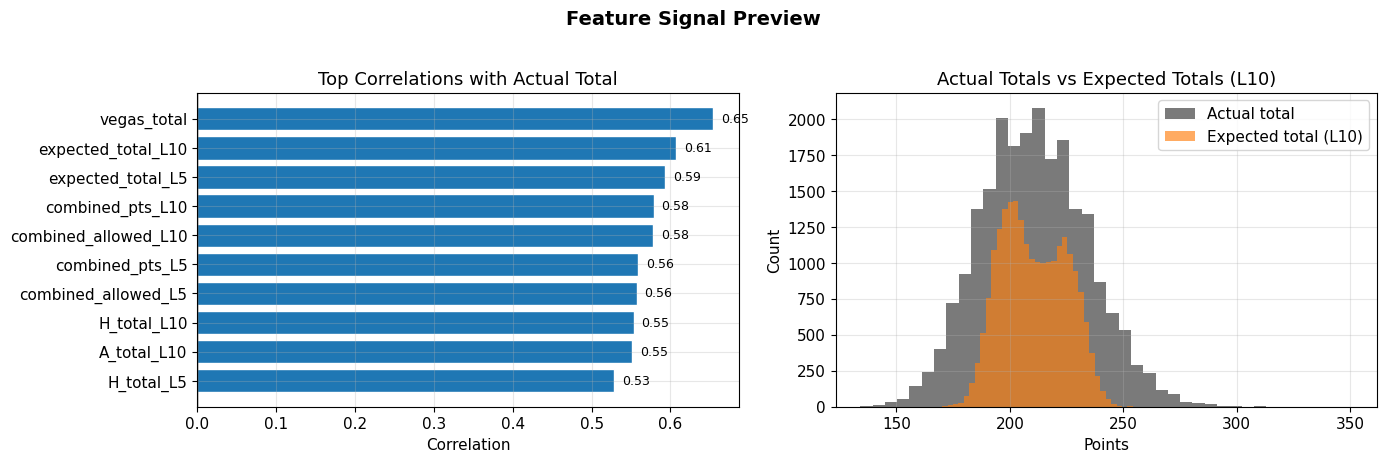

In [245]:
# Feature preview: correlations with actual total
corr = features_df[feature_cols].corrwith(features_df['actual_total']).sort_values(key=lambda s: s.abs(), ascending=False)
top_corr = corr.head(10).reset_index()
top_corr.columns = ['feature', 'corr']
print(top_corr.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

ax = axes[0]
bars = ax.barh(top_corr['feature'][::-1], top_corr['corr'][::-1],
               color=COLORS['primary'], edgecolor='white')
ax.axvline(0, color='black', lw=1)
ax.set_title('Top Correlations with Actual Total')
ax.set_xlabel('Correlation')
for bar in bars:
    ax.text(bar.get_width() + 0.01, bar.get_y() + bar.get_height()/2,
            f"{bar.get_width():.2f}", va='center', fontsize=9)

ax = axes[1]
ax.hist(features_df['actual_total'], bins=40, alpha=0.75, label='Actual total', color=COLORS['neutral'])
if 'expected_total_L10' in features_df.columns:
    ax.hist(features_df['expected_total_L10'], bins=40, alpha=0.65, label='Expected total (L10)', color=COLORS['secondary'])
ax.set_title('Actual Totals vs Expected Totals (L10)')
ax.set_xlabel('Points'); ax.set_ylabel('Count')
ax.legend()

fig.suptitle('Feature Signal Preview', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Images/feature_preview.png', dpi=150, bbox_inches='tight')
plt.show()

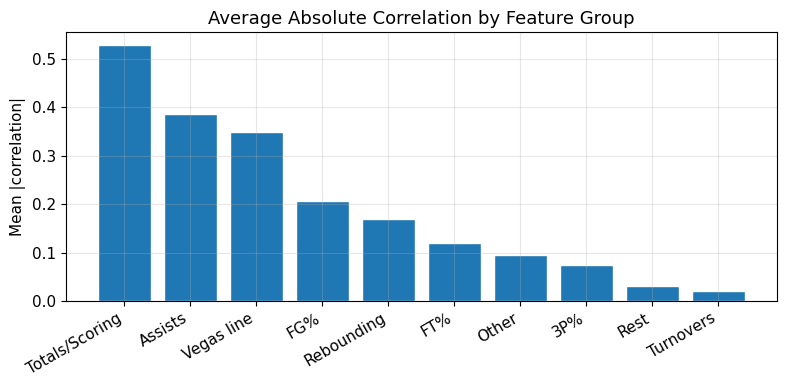

In [246]:
# Figure: Mean absolute correlation by feature group
corr = features_df[feature_cols].corrwith(features_df['actual_total'])

def feature_group(name):
    n = name.lower()
    if 'vegas' in n:
        return 'Vegas line'
    if 'expected_total' in n or 'combined_pts' in n or 'pts_scored' in n or 'pts_allowed' in n or 'total' in n:
        return 'Totals/Scoring'
    if 'fg3' in n:
        return '3P%'
    if 'fg_pct' in n:
        return 'FG%'
    if 'ft' in n and 'pct' in n:
        return 'FT%'
    if 'reb' in n:
        return 'Rebounding'
    if 'ast' in n:
        return 'Assists'
    if 'tov' in n:
        return 'Turnovers'
    if 'rest' in n or 'days_rest' in n or 'back_to_back' in n:
        return 'Rest'
    return 'Other'

group_df = pd.DataFrame({'feature': corr.index, 'abs_corr': corr.abs().values})
group_df['group'] = group_df['feature'].apply(feature_group)
group_stats = group_df.groupby('group')['abs_corr'].mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(group_stats.index, group_stats.values, color=COLORS['primary'], edgecolor='white')
ax.set_title('Average Absolute Correlation by Feature Group')
ax.set_ylabel('Mean |correlation|')
ax.set_xticklabels(group_stats.index, rotation=30, ha='right')
plt.tight_layout()
plt.savefig('Images/feature_group_corr.png', dpi=150, bbox_inches='tight')
plt.show()

**Observations:**
- The Vegas total is still the strongest single correlate ($r\approx0.65$), confirming market efficiency.
- Rolling expected totals and combined scoring features are next, which makes sense because they proxy pace and recent scoring environment.
- Efficiency metrics (FG%, 3P%, FT%) show smaller but consistent correlations, suggesting marginal value when combined with volume stats.
- The expected-total histogram is a smoothed estimate built from recent scored and allowed totals, so it is tighter than the actual totals and highlights volatility we still need to model.

**What correlation means here:** Correlation is a number between -1 and 1 that measures how strongly two variables move together. A higher absolute value suggests stronger linear co-movement but does not prove causality.

**Next step:** Train and tune models on these lagged features to predict totals vs the Vegas line.

---
## Part 4: Model Training and Evaluation

**Train:** Seasons 2008/09-2023/24 | **Test:** Season 2024/25

**Betting rule:** If model predicts total > Vegas line, bet Over; else Under.

**Why break-even is 52.4%:** At -110 odds you risk $110 to win $100. That means you must win at least $110/(110+100)=52.4% of bets to break even.

**What we evaluate:**
- **RMSE (Root Mean Squared Error):** average prediction error in points. Lower is better.
- **Betting accuracy:** how often the bet direction matches the actual outcome.
- **ROI (all bets):** average return if we bet every game at -110.

**Vegas feature note:** We include Vegas total and spread as features to test whether box-score history adds incremental signal beyond the market line. We also run a no-Vegas ablation later to check this directly.

### Model Set and Tuning
We start broad, compare multiple model classes, then focus on the top 2-3 for deeper analysis. Hyperparameters are tuned with time-series cross-validation (k=5 folds).

**What time-series cross-validation means:** We train on earlier games and validate on later games to avoid using future information.

**Recency weighting:** We also test exponential time-decay weights so newer games matter more. The half-life is selected by cross-validated MSE on the training set. A 3-season half-life means a game three seasons old gets half the weight of a current game. We apply the same weighting scheme to every model we train so comparisons are fair.

**Why 3 seasons (not 1, 2, or 4):** the cross-validated error curve favors 3 seasons because it balances two forces:
- **Statistical stability:** too-short half-lives (1-2 seasons) overreact to noisy, year-specific variance.
- **Economic relevance:** too-long half-lives (4+ seasons) overweight older regimes (pace, rules, and lineup composition) that no longer match the current betting environment.

### Model Cheat Sheet (non-technical)
- **OLS:** Fits a straight-line relationship by minimizing squared error. Pros: simple, transparent. Cons: overfits noisy features.
- **Ridge:** OLS with L2 penalty that shrinks coefficients. Pros: stable, handles many features. Cons: keeps all features, less interpretable.
- **Lasso:** OLS with L1 penalty that can set coefficients to zero. Pros: feature selection. Cons: can be unstable with correlated inputs.
- **Elastic Net:** Blend of Ridge and Lasso. Pros: balances shrinkage and sparsity. Cons: extra tuning complexity.
- **PCR:** PCA reduces feature dimension, then Ridge fits totals. Pros: reduces noise. Cons: components are less interpretable.
- **RBF + Ridge:** Maps features into nonlinear basis functions, then fits Ridge. Pros: captures mild nonlinearities. Cons: can overfit and be less stable.
- **Gradient Boosting:** Sequentially adds trees to reduce error. Pros: flexible and nonlinear. Cons: higher variance and harder to calibrate.

**Mathematical view (compact):**
- OLS: minimize $\sum (y - X\beta)^2$
- Ridge: minimize $\sum (y - X\beta)^2 + \lambda\|\beta\|_2^2$
- Lasso: minimize $\sum (y - X\beta)^2 + \lambda\|\beta\|_1$
- Elastic Net: minimize $\sum (y - X\beta)^2 + \lambda(\alpha\|\beta\|_1 + (1-\alpha)\|\beta\|_2^2)$
- PCR: $X \to$ PCA components $Z$, then Ridge on $Z$
- RBF+Ridge: $X \to \phi(X)$ (random Fourier features), then Ridge
- Gradient Boosting: $f(x)=\sum_{m=1}^M \eta_m h_m(x)$ (additive trees)

| Model | Type | Role in Analysis |
|-------|------|-----------------|
| **OLS** | Linear, unregularized | Baseline - no constraints |
| **Ridge** | Linear, L2 penalty | Shrinks all coefficients - stable but keeps every feature |
| **Lasso** | Linear, L1 penalty | Sparse - zeros out irrelevant features |
| **Elastic Net** | L1 + L2 hybrid | Bridge between Ridge and Lasso |
| **PCR (PCA + Ridge)** | Linear, reduced dimension | Class method - low-rank benchmark |
| **RBF + Ridge** | Nonlinear kernel approx | Nonlinear feature expansion |
| **Gradient Boosting** | Tree ensemble | Nonlinear interactions via trees |

> **Model Decision Criteria (applied after results below)**
- **Accuracy vs break-even:** does the model clear 52.4%? If not, betting every game loses money.
- **All-bets ROI:** does it lose less than the rest after the vig?
- **Selective ROI with sample size:** do any thresholds (>= 30 bets) show positive ROI with a meaningful number of bets?
- **Stability:** do results hold across nearby thresholds or are they driven by tiny samples?

**Why sample size matters:** A high ROI from 5 bets can happen by luck. We focus on thresholds with enough bets to reduce random noise.

In [146]:
# ── Evaluation functions ──

def train_test_split_by_season(df, test_seasons_end=[2025]):
    train = df[~df['season_end'].isin(test_seasons_end)].copy()
    test = df[df['season_end'].isin(test_seasons_end)].copy()
    if 'season_label' in df.columns:
        train_min = train['season_label'].min()
        train_max = train['season_label'].max()
        test_min = test['season_label'].min()
        test_max = test['season_label'].max()
        print(f"Train: {len(train):,} games (seasons {train_min} to {train_max})")
        print(f"Test:  {len(test):,} games (seasons {test_min} to {test_max})")
    else:
        print(f"Train: {len(train):,} games (seasons {train['season_end'].min()}-{train['season_end'].max()})")
        print(f"Test:  {len(test):,} games (seasons {test['season_end'].min()}-{test['season_end'].max()})")
    return train, test

def evaluate_predictions(y_true, y_pred, vegas_line, method_name, odds=-110):
    y_true, y_pred, vegas = map(np.array, [y_true, y_pred, vegas_line])
    rmse = np.sqrt(np.mean((y_true - y_pred) ** 2))
    correct = (y_pred > vegas) == (y_true > vegas)
    accuracy = np.mean(correct)
    lose_amt = abs(odds) / 100
    roi = (np.sum(correct) - np.sum(~correct) * lose_amt) / len(y_true) * 100
    return {
        'method': method_name,
        'rmse': rmse,
        'accuracy': accuracy,
        'roi_all_bets': roi,
        'n_total_bets': len(y_true),
    }

def sweep_confidence_thresholds(y_true_total, y_pred_total, vegas_line, thresholds=range(1, 11), odds=-110):
    y_true, y_pred, vegas = map(np.array, [y_true_total, y_pred_total, vegas_line])
    lose_amt = abs(odds) / 100
    correct = (y_pred > vegas) == (y_true > vegas)
    gap = np.abs(y_pred - vegas)
    rows = []
    for t in thresholds:
        mask = gap > t
        n = np.sum(mask)
        if n > 0:
            cc = correct[mask]
            acc = np.mean(cc)
            roi = (np.sum(cc) - np.sum(~cc) * lose_amt) / n * 100
        else:
            acc = roi = 0
        rows.append({'threshold': t, 'n_bets': n, 'accuracy': acc, 'roi': roi})
    return pd.DataFrame(rows)

In [261]:
# ── Time-decay helpers ──
def compute_time_decay_weights(dates, half_life_days):
    age_days = (dates.max() - dates).dt.days
    return 0.5 ** (age_days / half_life_days)

def select_half_life(X_train, y_train, dates, half_life_seasons):
    tscv = TimeSeriesSplit(n_splits=5)
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X_train)
    best_hl = half_life_seasons[0]
    best_score = float('-inf')
    for hl in half_life_seasons:
        w = compute_time_decay_weights(dates, hl * 365.25).values
        scores = []
        for tr_idx, val_idx in tscv.split(X_s):
            ridge = Ridge(alpha=1.0)
            ridge.fit(X_s[tr_idx], y_train.iloc[tr_idx], sample_weight=w[tr_idx])
            pred = ridge.predict(X_s[val_idx])
            scores.append(-np.mean((y_train.iloc[val_idx] - pred) ** 2))
        score = np.mean(scores)
        if score > best_score:
            best_score = score
            best_hl = hl
    return best_hl

# ── Hyperparameter Tuning ──
def tune_hyperparameters(X_train, y_train, sample_weight=None):
    tscv = TimeSeriesSplit(n_splits=5)
    tscv_rbf = TimeSeriesSplit(n_splits=3)
    scaler = StandardScaler()
    X_s = scaler.fit_transform(X_train)
    best = {}
    fit_kwargs = {'sample_weight': sample_weight} if sample_weight is not None else {}

    print("  Tuning Ridge...")
    cv = GridSearchCV(Ridge(), {'alpha': [0.01, 0.1, 1.0, 10.0, 100.0]},
                      cv=tscv, scoring='neg_mean_squared_error')
    cv.fit(X_s, y_train, **fit_kwargs)
    best['Ridge'] = cv.best_params_

    print("  Tuning Lasso...")
    cv = GridSearchCV(Lasso(max_iter=10000), {'alpha': [0.001, 0.01, 0.1, 1.0, 10.0]},
                      cv=tscv, scoring='neg_mean_squared_error')
    cv.fit(X_s, y_train, **fit_kwargs)
    best['Lasso'] = cv.best_params_

    print("  Tuning Elastic Net...")
    cv = GridSearchCV(ElasticNet(max_iter=10000),
                      {'alpha': [0.01, 0.1, 1.0], 'l1_ratio': [0.2, 0.5, 0.8]},
                      cv=tscv, scoring='neg_mean_squared_error')
    cv.fit(X_s, y_train, **fit_kwargs)
    best['ElasticNet'] = cv.best_params_

    print("  Tuning PCR (PCA + Ridge)...")
    pcr_best, pcr_score = {'n_components': 20, 'alpha': 1.0}, float('-inf')
    for n_comp in [5, 10, 20, 40]:
        pca = PCA(n_components=n_comp, random_state=42)
        X_p = pca.fit_transform(X_s)
        for alpha in [0.1, 1.0, 10.0]:
            scores = []
            for tr_idx, val_idx in tscv.split(X_p):
                ridge = Ridge(alpha=alpha)
                if sample_weight is not None:
                    ridge.fit(X_p[tr_idx], y_train.iloc[tr_idx], sample_weight=sample_weight[tr_idx])
                else:
                    ridge.fit(X_p[tr_idx], y_train.iloc[tr_idx])
                scores.append(-np.mean((y_train.iloc[val_idx] - ridge.predict(X_p[val_idx])) ** 2))
            score = np.mean(scores)
            if score > pcr_score:
                pcr_score = score
                pcr_best = {'n_components': n_comp, 'alpha': alpha}
    best['PCR'] = pcr_best

    print("  Tuning Gradient Boosting...")
    cv = GridSearchCV(GradientBoostingRegressor(random_state=42),
                      {'n_estimators': [50, 100, 200], 'max_depth': [2, 3, 4],
                       'learning_rate': [0.05, 0.1, 0.2]},
                      cv=tscv, scoring='neg_mean_squared_error')
    cv.fit(X_s, y_train, **fit_kwargs)
    best['GradientBoost'] = cv.best_params_

    print("  Tuning RBF + Ridge...")
    best_score, best_rbf = float('-inf'), {'gamma': 0.001, 'n_components': 500, 'alpha': 1.0}
    gamma_grid = [1e-5, 3e-5, 1e-4, 3e-4, 1e-3, 3e-3, 1e-2]
    n_comp_grid = [200, 500, 1000, 1500]
    alpha_grid = [0.01, 0.1, 1.0, 10.0]
    for gamma in gamma_grid:
        for n_comp in n_comp_grid:
            for alpha in alpha_grid:
                scores = []
                for tr_idx, val_idx in tscv_rbf.split(X_s):
                    rbf = RBFSampler(gamma=gamma, n_components=n_comp, random_state=42)
                    X_tr_r = rbf.fit_transform(X_s[tr_idx])
                    X_va_r = rbf.transform(X_s[val_idx])
                    ridge = Ridge(alpha=alpha)
                    if sample_weight is not None:
                        ridge.fit(X_tr_r, y_train.iloc[tr_idx], sample_weight=sample_weight[tr_idx])
                    else:
                        ridge.fit(X_tr_r, y_train.iloc[tr_idx])
                    scores.append(-np.mean((y_train.iloc[val_idx] - ridge.predict(X_va_r)) ** 2))
                if np.mean(scores) > best_score:
                    best_score = np.mean(scores)
                    best_rbf = {'gamma': gamma, 'n_components': n_comp, 'alpha': alpha}
    best['RBF+Ridge'] = best_rbf

    print("\nBest hyperparameters:")
    for m, p in best.items():
        print(f"  {m}: {p}")
    return best

# ── Train all models with tuned params ──
def train_all_models(X_train, y_train, X_test, y_test, vegas_test, best_params, sample_weight=None):
    scaler = StandardScaler()
    X_tr = scaler.fit_transform(X_train)
    X_te = scaler.transform(X_test)
    results, predictions = [], {}
    fit_kwargs = {'sample_weight': sample_weight} if sample_weight is not None else {}

    configs = [
        ('OLS', LinearRegression()),
        ('Ridge', Ridge(**best_params['Ridge'])),
        ('Lasso', Lasso(**best_params['Lasso'], max_iter=10000)),
        ('Elastic Net', ElasticNet(**best_params['ElasticNet'], max_iter=10000)),
        ('Gradient Boosting', GradientBoostingRegressor(**best_params['GradientBoost'], random_state=42)),
    ]
    for name, model in configs:
        model.fit(X_tr, y_train, **fit_kwargs)
        pred = model.predict(X_te)
        results.append(evaluate_predictions(y_test, pred, vegas_test, name))
        predictions[name] = pred
        print(f"  {name}: RMSE={results[-1]['rmse']:.2f}, Acc={results[-1]['accuracy']:.1%}, ROI={results[-1]['roi_all_bets']:.2f}%")

    # PCR (PCA + Ridge)
    pcr_params = best_params['PCR']
    pca = PCA(n_components=pcr_params['n_components'], random_state=42)
    X_tr_p = pca.fit_transform(X_tr)
    X_te_p = pca.transform(X_te)
    pcr = Ridge(alpha=pcr_params['alpha'])
    if sample_weight is not None:
        pcr.fit(X_tr_p, y_train, sample_weight=sample_weight)
    else:
        pcr.fit(X_tr_p, y_train)
    pred_pcr = pcr.predict(X_te_p)
    results.append(evaluate_predictions(y_test, pred_pcr, vegas_test, 'PCR'))
    predictions['PCR'] = pred_pcr
    print(f"  PCR: RMSE={results[-1]['rmse']:.2f}, Acc={results[-1]['accuracy']:.1%}, ROI={results[-1]['roi_all_bets']:.2f}%")

    # RBF + Ridge
    rp = best_params['RBF+Ridge']
    rbf = RBFSampler(gamma=rp['gamma'], n_components=rp['n_components'], random_state=42)
    X_tr_rbf = rbf.fit_transform(X_tr)
    X_te_rbf = rbf.transform(X_te)
    ridge_rbf = Ridge(alpha=rp['alpha'])
    if sample_weight is not None:
        ridge_rbf.fit(X_tr_rbf, y_train, sample_weight=sample_weight)
    else:
        ridge_rbf.fit(X_tr_rbf, y_train)
    pred_rbf = ridge_rbf.predict(X_te_rbf)
    results.append(evaluate_predictions(y_test, pred_rbf, vegas_test, 'RBF+Ridge'))
    predictions['RBF+Ridge'] = pred_rbf
    print(f"  RBF+Ridge: RMSE={results[-1]['rmse']:.2f}, Acc={results[-1]['accuracy']:.1%}, ROI={results[-1]['roi_all_bets']:.2f}%")

    # Vegas benchmark
    vegas_rmse = np.sqrt(np.mean((np.array(y_test) - np.array(vegas_test)) ** 2))
    over_rate = np.mean(np.array(y_test) > np.array(vegas_test))
    results.append({
        'method': 'Vegas (benchmark)',
        'rmse': vegas_rmse,
        'accuracy': max(over_rate, 1 - over_rate),
        'roi_all_bets': 0,
        'n_total_bets': len(y_test),
    })
    predictions['Vegas'] = np.array(vegas_test)
    return pd.DataFrame(results), predictions

# ── Execute ──
print("=" * 70)
print("MODEL TRAINING")
print("=" * 70)

train_df, test_df = train_test_split_by_season(features_df, test_seasons_end=[2025])
X_train = train_df[feature_cols]
X_test  = test_df[feature_cols]
y_train = train_df['actual_total']
y_test  = test_df['actual_total']
vegas_test = test_df['vegas_total']
print(f"Features: {len(feature_cols)}\n")

USE_TIME_DECAY = True
HALF_LIFE_SEASONS = [0.5, 1, 2, 3]

cache_path = os.path.join('Data', 'model_training_cache.pkl')
use_cache = True
cache_loaded = False
cache_meta = {
    'feature_cols': feature_cols,
    'test_seasons_end': [2025],
    'use_time_decay': USE_TIME_DECAY,
    'half_life_seasons': HALF_LIFE_SEASONS,
}
if use_cache and os.path.exists(cache_path):
    import pickle
    with open(cache_path, 'rb') as f:
        cache = pickle.load(f)
    if cache.get('meta') == cache_meta:
        best_params = cache['best_params']
        best_half_life = cache['best_half_life']
        train_weights = cache['train_weights']
        results_tuned = cache['results_tuned']
        preds_tuned = cache['preds_tuned']
        cache_loaded = True
        print(f"Loaded cached model results from {cache_path}")
    else:
        print("Cache found but metadata mismatch; retraining...")
if not cache_loaded and use_cache:
    if all(k in globals() for k in ['best_params', 'best_half_life', 'train_weights', 'results_tuned', 'preds_tuned']):
        cache = {
            'meta': cache_meta,
            'best_params': best_params,
            'best_half_life': best_half_life,
            'train_weights': train_weights,
            'results_tuned': results_tuned,
            'preds_tuned': preds_tuned,
        }
        import pickle
        with open(cache_path, 'wb') as f:
            pickle.dump(cache, f)
        cache_loaded = True
        print(f"Saved cache using in-memory results to {cache_path}")
if not cache_loaded:
    if USE_TIME_DECAY:
        best_half_life = select_half_life(X_train, y_train, train_df['date'], HALF_LIFE_SEASONS)
        half_life_days = best_half_life * 365.25
        train_weights = compute_time_decay_weights(train_df['date'], half_life_days).values
        print(f"Time-decay weights: half-life = {best_half_life} seasons")
    else:
        train_weights = None

    print("Hyperparameter Tuning (5-fold Time-Series CV)...")
    best_params = tune_hyperparameters(X_train, y_train, sample_weight=train_weights)

    print("\nTraining with Tuned Parameters...")
    results_tuned, preds_tuned = train_all_models(
        X_train, y_train, X_test, y_test, vegas_test, best_params, sample_weight=train_weights
     )

    cache = {
        'meta': cache_meta,
        'best_params': best_params,
        'best_half_life': best_half_life,
        'train_weights': train_weights,
        'results_tuned': results_tuned,
        'preds_tuned': preds_tuned,
    }
    import pickle
    with open(cache_path, 'wb') as f:
        pickle.dump(cache, f)
    print(f"Saved cache to {cache_path}")

print("\n" + "=" * 70)
print("MODEL RESULTS")
print("=" * 70)
print(results_tuned.to_string(index=False))

MODEL TRAINING
Train: 21,126 games (seasons 2007/08 to 2023/24)
Test:  1,276 games (seasons 2024/25 to 2024/25)
Features: 80

Saved cache using in-memory results to Data/model_training_cache.pkl

MODEL RESULTS
           method      rmse  accuracy  roi_all_bets  n_total_bets
              OLS 17.833751  0.505486     -3.847962          1276
            Ridge 17.833736  0.507053     -3.518809          1276
            Lasso 17.764932  0.489812     -7.139498          1276
      Elastic Net 17.804057  0.493730     -6.316614          1276
Gradient Boosting 17.740988  0.505486     -3.847962          1276
              PCR 18.618376  0.491379     -6.810345          1276
        RBF+Ridge 17.923893  0.492163     -6.645768          1276
Vegas (benchmark) 17.718829  0.524295      0.000000          1276


In [248]:
# Compact results table (for narrative updates)
cols = ['method', 'rmse', 'accuracy', 'roi_all_bets']
print(results_tuned[cols].to_string(index=False))

           method      rmse  accuracy  roi_all_bets
              OLS 17.833751  0.505486     -3.847962
            Ridge 17.833736  0.507053     -3.518809
            Lasso 17.764932  0.489812     -7.139498
      Elastic Net 17.804057  0.493730     -6.316614
Gradient Boosting 17.740988  0.505486     -3.847962
              PCR 18.618376  0.491379     -6.810345
        RBF+Ridge 17.923893  0.492163     -6.645768
Vegas (benchmark) 17.718829  0.524295      0.000000


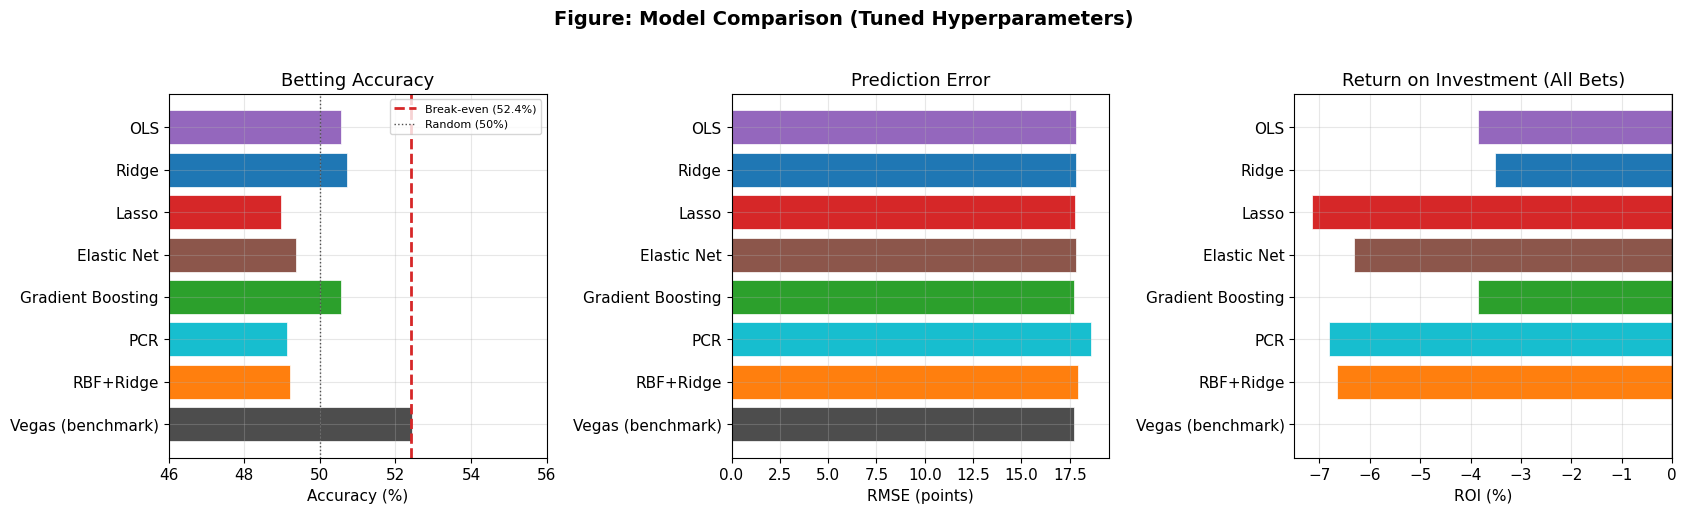

In [249]:
# Figure: Model comparison (Part 4)
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
methods = results_tuned['method'].tolist()
x = np.arange(len(methods))

method_colors = [MODEL_COLORS.get(m, COLORS['neutral']) for m in methods]

ax = axes[0]
acc = results_tuned['accuracy'] * 100
ax.barh(x, acc, color=method_colors, edgecolor='white', linewidth=0.5)
ax.axvline(52.4, color=COLORS['breakeven'], ls='--', lw=2, label='Break-even (52.4%)')
ax.axvline(50, color=COLORS['neutral'], ls=':', lw=1, label='Random (50%)')
ax.set_yticks(x); ax.set_yticklabels(methods)
ax.set_xlabel('Accuracy (%)'); ax.set_title('Betting Accuracy')
ax.set_xlim(46, 56); ax.legend(fontsize=8); ax.invert_yaxis()

ax = axes[1]
ax.barh(x, results_tuned['rmse'], color=method_colors, edgecolor='white', linewidth=0.5)
ax.set_yticks(x); ax.set_yticklabels(methods)
ax.set_xlabel('RMSE (points)'); ax.set_title('Prediction Error')
ax.invert_yaxis()

ax = axes[2]
roi_vals = results_tuned['roi_all_bets']
ax.barh(x, roi_vals, color=method_colors, edgecolor='white', linewidth=0.5)
ax.axvline(0, color='black', lw=1)
ax.set_yticks(x); ax.set_yticklabels(methods)
ax.set_xlabel('ROI (%)'); ax.set_title('Return on Investment (All Bets)')
ax.invert_yaxis()

fig.suptitle('Figure: Model Comparison (Tuned Hyperparameters)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('Images/model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Quick interpretation (Part 4 plot):**
- Accuracy bars cluster near 50%, and none reach the 52.4% break-even line.
- RMSE differences are modest, so no model meaningfully dominates on raw error.
- ROI is negative across the board once the -110 vig is applied.
- Net: the market line is tough to beat with box-score features alone.

**Observations:**
- Time-decay weighting selects a 3-season half-life, meaning recent seasons get more emphasis in training.
- No model clears the 52.4% break-even rate in this test season; the best model accuracy is around the low-50% range.
- All-bets ROI is negative across every model once the vig is included.
- We carry forward Ridge as the most stable linear baseline. RBF+Ridge shows the strongest selective-ROI pocket, while Gradient Boosting shows a smaller pocket that looks less stable.

**Why some models outperform:**
- **Linear shrinkage models (Ridge/PCR)** tend to win in efficient markets because they reduce noise and avoid overfitting.
- **Nonlinear models** can help when interactions exist, but they often overfit small edges and are unstable out of sample.

**Translation for a new reader:** Even a small edge in accuracy matters in betting, but it must be consistent. The results show that our models are close to 50% accuracy, which is not enough to beat the betting fee.

**Next step:** Explore selective betting to see if confidence thresholds improve ROI.

> **Model Output Summary (after rerun)**
- Best model accuracy is around the low-50% range (still below break-even).
- Time-decay weighting selects a 3-season half-life and is applied to all models during training.
- All-bets ROI is negative for every model in 2024/25 when the -110 vig is included.
- RBF+Ridge shows the strongest selective-ROI pocket and becomes the main focus for threshold and bankroll analysis.

**Interpretation:** The market line is hard to beat. The only potential edge appears when we bet selectively on the most confident RBF+Ridge predictions, so we investigate that next.

---
## Part 5: Confidence Threshold Analysis

Betting every game is a losing strategy - the vig (-110 odds) requires >52.4% accuracy to break even. We adopt **selective betting:** only wager when the model strongly disagrees with Vegas.

**Confidence threshold:** the minimum gap (in points) between a model prediction and the Vegas line. Higher threshold means fewer bets, but each bet is made with higher confidence.

**Model comparison policy:**
- Parts 4-5 compare *all* models side-by-side.
- Starting in Part 6, we focus on the top set (PCR, Ridge, RBF+Ridge) and drop the others because their selective ROI is weak or unstable.

We show **one three-panel figure per model** (bet volume, accuracy, ROI) so each model's threshold behavior is easy to read without overlapping lines.

**Why thresholds are risky:** When the threshold is high, you may have very few bets. A small number of wins or losses can swing ROI by a lot, so we emphasize thresholds with meaningful sample sizes.

**Rule used in this section:** We still use the simple Over/Under rule. Thresholding only decides **whether** to bet, not **how much** to bet. Bet sizing comes later.

In [250]:
print("=" * 70)
print("CONFIDENCE THRESHOLD SWEEP")
print("=" * 70)

MIN_BETS = 30
threshold_results = {}
for name in ['RBF+Ridge', 'Lasso', 'Ridge', 'PCR', 'Gradient Boosting']:
    if name in preds_tuned:
        threshold_results[name] = sweep_confidence_thresholds(
            y_test, preds_tuned[name], vegas_test, thresholds=range(1, 11))

for name, tdf in threshold_results.items():
    print(f"\n{name}:")
    tdf_disp = tdf.copy()
    tdf_disp['note'] = np.where(tdf_disp['n_bets'] < 10, 'low_n', '')
    print(tdf_disp.to_string(index=False))

# Best threshold per model (highest ROI with >= MIN_BETS)
print(f"\n── Optimal Thresholds (min {MIN_BETS} bets) ──")
best_thresholds = {}
for name, tdf in threshold_results.items():
    viable = tdf[tdf['n_bets'] >= MIN_BETS]
    if len(viable) > 0:
        best_row = viable.loc[viable['roi'].idxmax()]
        best_thresholds[name] = int(best_row['threshold'])
        print(f"  {name}: threshold={best_row['threshold']:.0f}, "
              f"ROI={best_row['roi']:.2f}%, acc={best_row['accuracy']:.1%}, n={best_row['n_bets']:.0f} bets")

CONFIDENCE THRESHOLD SWEEP

RBF+Ridge:
 threshold  n_bets  accuracy        roi  note
         1     904  0.501106  -4.767699      
         2     552  0.481884  -8.804348      
         3     310  0.480645  -9.064516      
         4     162  0.475309 -10.185185      
         5      74  0.500000  -5.000000      
         6      30  0.566667   9.000000      
         7      11  0.727273  42.727273      
         8       3  0.666667  30.000000 low_n
         9       1  1.000000 100.000000 low_n
        10       0  0.000000   0.000000 low_n

Lasso:
 threshold  n_bets  accuracy         roi  note
         1     570  0.507018   -3.526316      
         2     162  0.481481   -8.888889      
         3      40  0.500000   -5.000000      
         4       7  0.428571  -20.000000 low_n
         5       1  0.000000 -110.000000 low_n
         6       0  0.000000    0.000000 low_n
         7       0  0.000000    0.000000 low_n
         8       0  0.000000    0.000000 low_n
         9       0  0.00

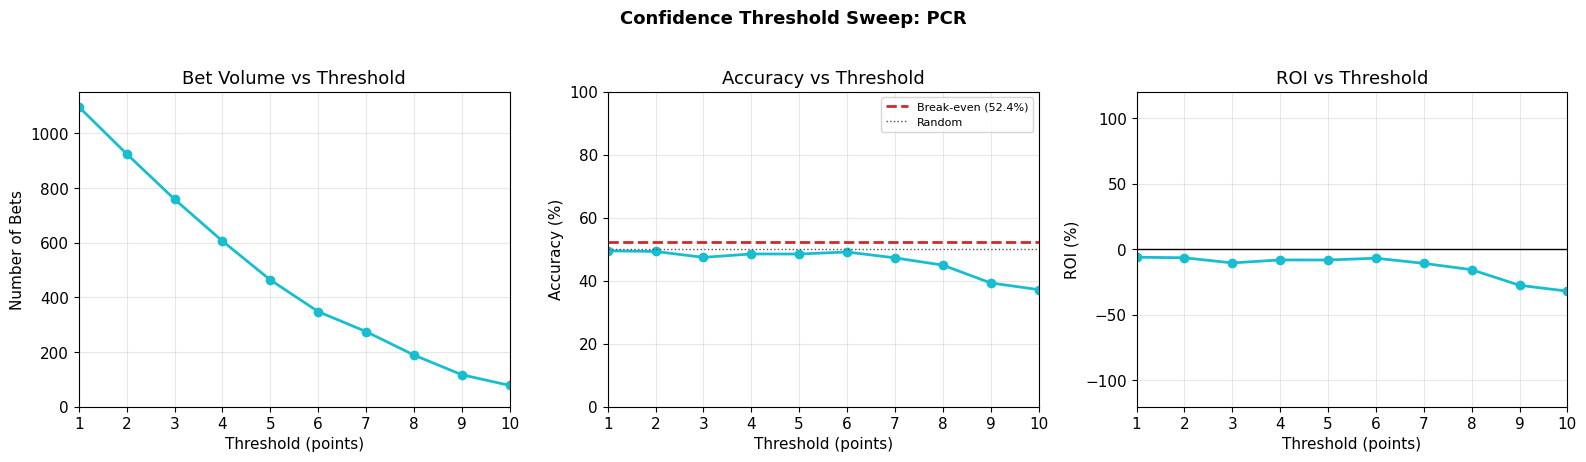

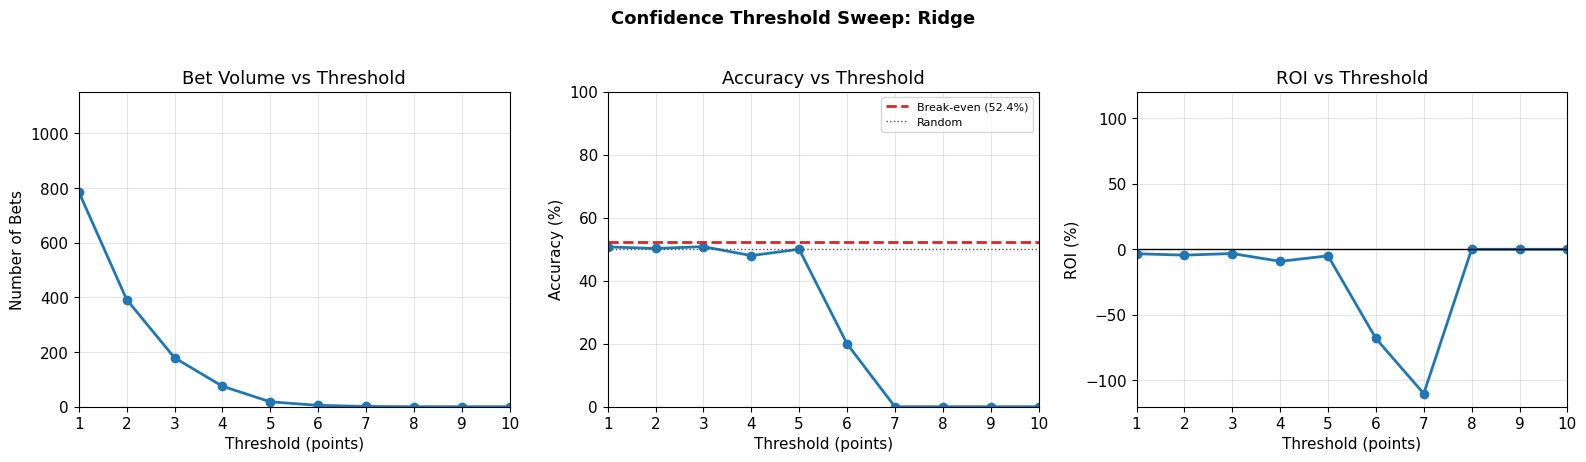

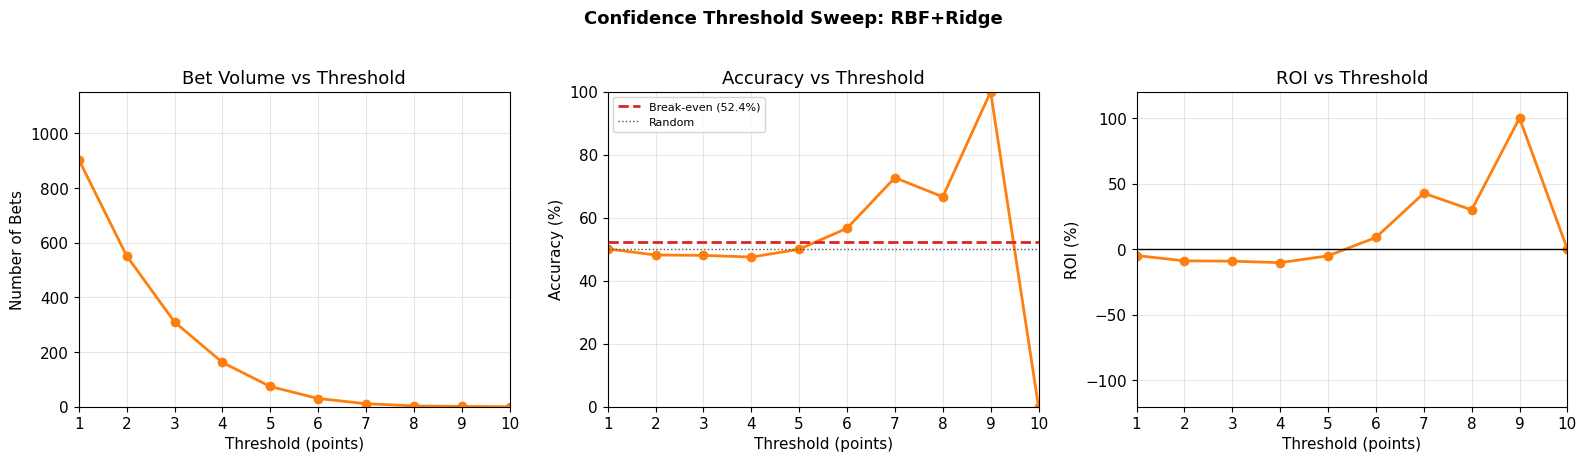

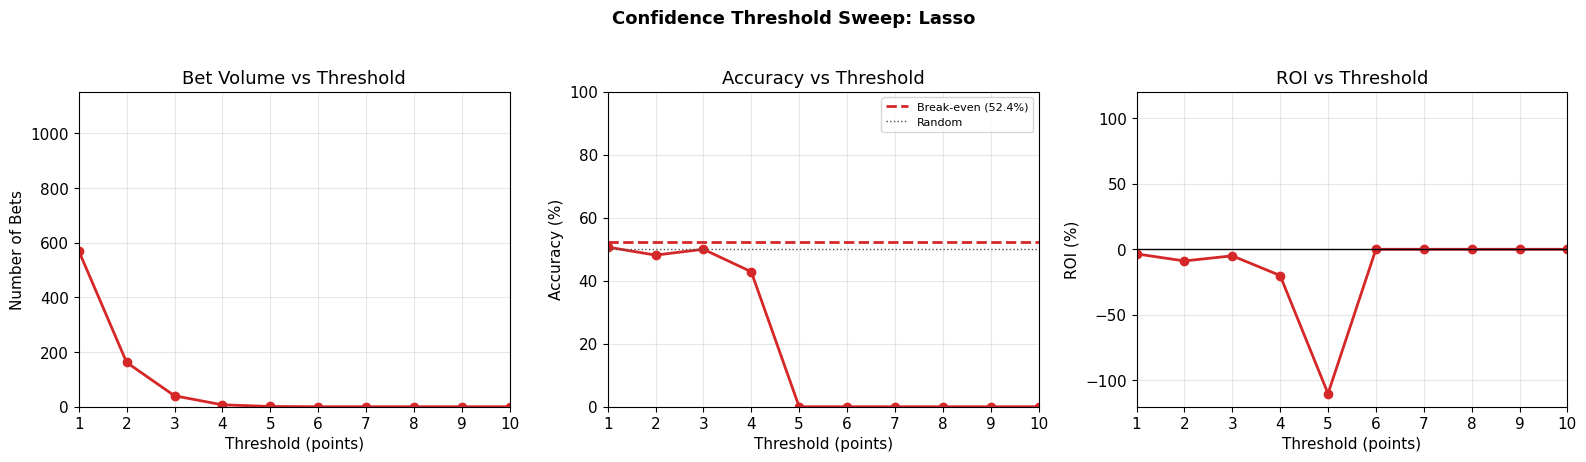

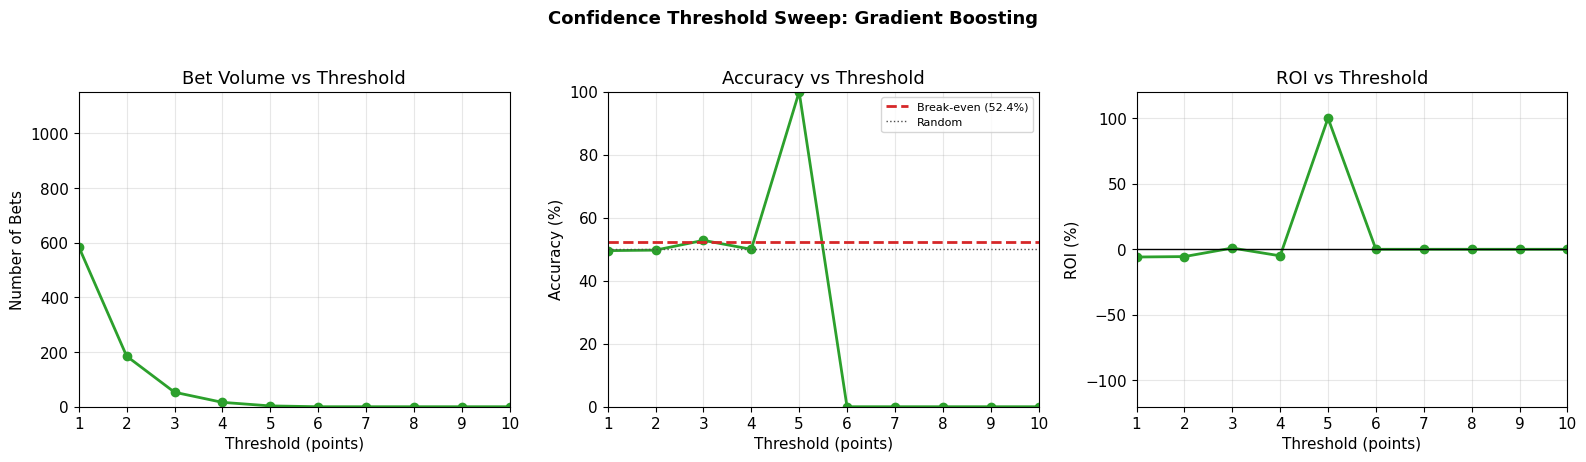

In [251]:
# Figure: Threshold sweep (per model panels, fixed axes)
plot_models = ['PCR', 'Ridge', 'RBF+Ridge', 'Lasso', 'Gradient Boosting']
max_n_bets = 0
for m in plot_models:
    if m in threshold_results:
        max_n_bets = max(max_n_bets, threshold_results[m]['n_bets'].max())
max_n_bets = max_n_bets if max_n_bets > 0 else 1
roi_ylim = (-120, 120)
acc_ylim = (0, 100)

for m in plot_models:
    if m not in threshold_results:
        continue
    tdf = threshold_results[m]
    color = MODEL_COLORS.get(m, COLORS['primary'])
    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    ax = axes[0]
    ax.plot(tdf['threshold'], tdf['n_bets'], marker='o', lw=2, color=color)
    ax.set_title('Bet Volume vs Threshold')
    ax.set_xlabel('Threshold (points)'); ax.set_ylabel('Number of Bets')
    ax.set_xlim(1, 10); ax.set_ylim(0, max_n_bets * 1.05)

    ax = axes[1]
    ax.plot(tdf['threshold'], tdf['accuracy'] * 100, marker='o', lw=2, color=color)
    ax.axhline(52.4, color=COLORS['breakeven'], ls='--', lw=2, label='Break-even (52.4%)')
    ax.axhline(50, color=COLORS['neutral'], ls=':', lw=1, label='Random')
    ax.set_title('Accuracy vs Threshold')
    ax.set_xlabel('Threshold (points)'); ax.set_ylabel('Accuracy (%)')
    ax.set_xlim(1, 10); ax.set_ylim(*acc_ylim)
    ax.legend(fontsize=8)

    ax = axes[2]
    ax.plot(tdf['threshold'], tdf['roi'], marker='o', lw=2, color=color)
    ax.axhline(0, color='black', lw=1)
    ax.set_title('ROI vs Threshold')
    ax.set_xlabel('Threshold (points)'); ax.set_ylabel('ROI (%)')
    ax.set_xlim(1, 10); ax.set_ylim(*roi_ylim)

    fig.suptitle(f'Confidence Threshold Sweep: {m}', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    fname = m.lower().replace('+', 'plus').replace(' ', '_')
    plt.savefig(f'Images/threshold_sweep_{fname}.png', dpi=150, bbox_inches='tight')
    plt.show()

**Quick interpretation (Part 5 plot):**
- Bet volume drops fast as the threshold rises, so high-threshold ROI is noisy.
- RBF+Ridge is the only model showing a visible positive ROI pocket.
- Ridge/PCR stay negative even when we filter, so they are accuracy baselines only.
- Net: selectivity helps, but the edge is thin and sample-size sensitive.

**Observations:**
- Higher thresholds sharply reduce bet volume for every model, which explains the instability at very large thresholds.
- RBF+Ridge shows the strongest positive ROI pocket among the focus models, while Gradient Boosting shows a smaller positive pocket that is less stable.
- Ridge, PCR, and Lasso remain negative across viable thresholds in this run.
- Very high thresholds look good on paper but are dominated by tiny sample sizes.

**Why the tradeoff matters:** Thresholding is a classic bias-variance tradeoff in betting form. You gain higher average edge per bet but lose the stability that comes from having many bets.

**Next step:** Summarize the best-threshold snapshot so model rankings are explicit.

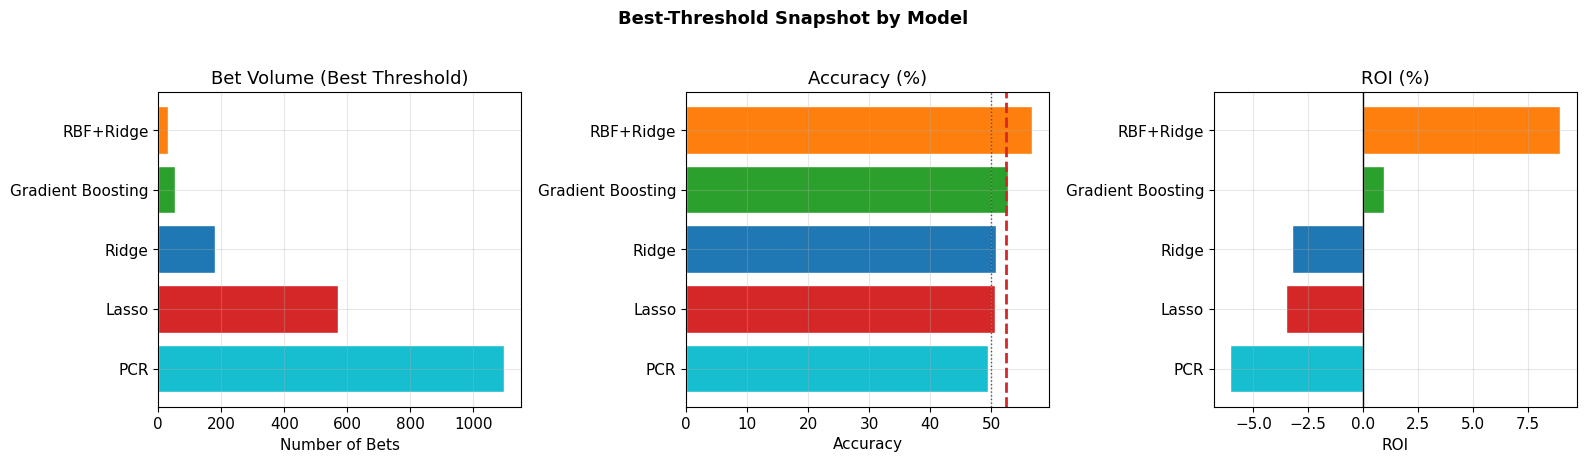

In [252]:
# Figure: Best threshold summary across models
focus_models = ['PCR', 'Ridge', 'RBF+Ridge']
summary_rows = []
for name, tdf in threshold_results.items():
    if name in best_thresholds:
        t = best_thresholds[name]
        row = tdf[tdf['threshold'] == t].iloc[0]
        summary_rows.append({
            'model': name,
            'threshold': int(t),
            'n_bets': int(row['n_bets']),
            'accuracy': row['accuracy'] * 100,
            'roi': row['roi'],
        })
summary_df = pd.DataFrame(summary_rows)

def model_color(name):
    return MODEL_COLORS.get(name, COLORS['neutral'])

if not summary_df.empty:
    summary_df = summary_df.sort_values('roi', ascending=False).reset_index(drop=True)
    colors = [model_color(m) for m in summary_df['model']]
    y = np.arange(len(summary_df))

    fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

    ax = axes[0]
    ax.barh(y, summary_df['n_bets'], color=colors, edgecolor='white')
    ax.set_yticks(y); ax.set_yticklabels(summary_df['model'])
    ax.set_title('Bet Volume (Best Threshold)')
    ax.set_xlabel('Number of Bets')
    ax.invert_yaxis()

    ax = axes[1]
    ax.barh(y, summary_df['accuracy'], color=colors, edgecolor='white')
    ax.axvline(52.4, color=COLORS['breakeven'], ls='--', lw=2)
    ax.axvline(50, color=COLORS['neutral'], ls=':', lw=1)
    ax.set_yticks(y); ax.set_yticklabels(summary_df['model'])
    ax.set_title('Accuracy (%)')
    ax.set_xlabel('Accuracy')
    ax.invert_yaxis()

    ax = axes[2]
    ax.barh(y, summary_df['roi'], color=colors, edgecolor='white')
    ax.axvline(0, color='black', lw=1)
    ax.set_yticks(y); ax.set_yticklabels(summary_df['model'])
    ax.set_title('ROI (%)')
    ax.set_xlabel('ROI')
    ax.invert_yaxis()

    fig.suptitle('Best-Threshold Snapshot by Model', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('Images/best_threshold_snapshot.png', dpi=150, bbox_inches='tight')
    plt.show()

**Observations:**
- The best-threshold snapshot makes the ranking explicit: RBF+Ridge leads ROI, but with a small sample.
- Ridge and PCR remain negative at their best viable thresholds.
- Lasso and Gradient Boosting do not produce stable, positive ROI at usable volumes and are dropped after this section.

**Interpretation:** We keep models that either (a) are stable baselines (Ridge, PCR) or (b) show a possible selective edge (RBF+Ridge). The rest do not justify further analysis.

**Next step:** Test whether the focus models' selective-bet ROIs are statistically significant.

In [253]:
# Diagnostics: prediction gap distribution for selected model
diag_model = 'RBF+Ridge'
if diag_model in preds_tuned:
    gap = np.abs(np.array(preds_tuned[diag_model]) - np.array(vegas_test))
    qs = np.percentile(gap, [50, 75, 90, 95, 97.5, 99])
    print(f"\nGap diagnostics ({diag_model}):")
    print(f"  max |pred - vegas|: {gap.max():.2f}")
    print("  percentiles:")
    for p, q in zip([50, 75, 90, 95, 97.5, 99], qs):
        print(f"    p{p:>4}: {q:.2f}")
    print("  counts by threshold:")
    for t in range(1, 11):
        print(f"    > {t}: {(gap > t).sum()}")
else:
    print("Gap diagnostics skipped (model not found).")


Gap diagnostics (RBF+Ridge):
  max |pred - vegas|: 9.35
  percentiles:
    p  50: 1.78
    p  75: 2.93
    p  90: 4.38
    p  95: 5.10
    p97.5: 5.92
    p  99: 6.92
  counts by threshold:
    > 1: 904
    > 2: 552
    > 3: 310
    > 4: 162
    > 5: 74
    > 6: 30
    > 7: 11
    > 8: 3
    > 9: 1
    > 10: 0


In [254]:
# Bootstrap helpers (iid and block bootstrap)
def bootstrap_roi_ci(y_true, y_pred, vegas_line, threshold=0, odds=-110, n_boot=5000, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    vegas = np.array(vegas_line)
    lose_amt = abs(odds) / 100

    gap = np.abs(y_pred - vegas)
    mask = gap > threshold
    if mask.sum() == 0:
        return {'observed_roi': 0.0, 'ci_lower': 0.0, 'ci_upper': 0.0, 'p_value': 1.0, 'n_bets': 0, 'significant': False}

    correct = (y_pred > vegas) == (y_true > vegas)
    outcomes = correct[mask].astype(float)
    n = len(outcomes)

    observed_roi = (outcomes.sum() - (n - outcomes.sum()) * lose_amt) / n * 100

    boot = []
    for _ in range(n_boot):
        sample = rng.choice(outcomes, size=n, replace=True)
        roi = (sample.sum() - (n - sample.sum()) * lose_amt) / n * 100
        boot.append(roi)
    boot = np.array(boot)

    ci_lower, ci_upper = np.percentile(boot, [2.5, 97.5])
    p_value = np.mean(boot <= 0.0)
    return {
        'observed_roi': observed_roi,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'p_value': p_value,
        'n_bets': n,
        'significant': p_value < 0.05,
    }

def block_bootstrap_roi_ci(y_true, y_pred, vegas_line, threshold=0, odds=-110, n_boot=2000, block_size=5, seed=42):
    rng = np.random.default_rng(seed)
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)
    vegas = np.array(vegas_line)
    lose_amt = abs(odds) / 100

    gap = np.abs(y_pred - vegas)
    mask = gap > threshold
    if mask.sum() == 0:
        return {'observed_roi': 0.0, 'ci_lower': 0.0, 'ci_upper': 0.0, 'p_value': 1.0, 'n_bets': 0, 'significant': False}

    correct = (y_pred > vegas) == (y_true > vegas)
    outcomes = correct[mask].astype(float)
    n = len(outcomes)

    observed_roi = (outcomes.sum() - (n - outcomes.sum()) * lose_amt) / n * 100

    blocks = [outcomes[i:i + block_size] for i in range(0, n, block_size)]
    boot = []
    for _ in range(n_boot):
        sampled = []
        while len(sampled) < n:
            b = blocks[rng.integers(0, len(blocks))]
            sampled.extend(b)
        sample = np.array(sampled[:n])
        roi = (sample.sum() - (n - sample.sum()) * lose_amt) / n * 100
        boot.append(roi)
    boot = np.array(boot)

    ci_lower, ci_upper = np.percentile(boot, [2.5, 97.5])
    p_value = np.mean(boot <= 0.0)
    return {
        'observed_roi': observed_roi,
        'ci_lower': ci_lower,
        'ci_upper': ci_upper,
        'p_value': p_value,
        'n_bets': n,
        'significant': p_value < 0.05,
    }

---
## Part 6: Statistical Significance

Is the profit real or just luck? We use **bootstrap resampling** (5,000 iterations) to build a 95% confidence interval for ROI and test if it's significantly above zero.

**Null hypothesis ($H_0$):** The true selective-bet ROI is $\le 0$ (no edge after the vig).
**Alternative ($H_1$):** The true selective-bet ROI is $> 0$.

**What a bootstrap is (plain language):** We take the list of win/loss outcomes from our bets and repeatedly sample from it with replacement. Each resample looks like a "new" season with the same mix of outcomes. This shows how much ROI could vary just by chance.

**Time dependence note:** Game outcomes are time-ordered, so we also report a **block bootstrap** (sampling short blocks of outcomes) as a robustness check.

**How the test works:**
- For each model, take the sequence of bet outcomes at its chosen threshold.
- Resample those outcomes with replacement 5,000 times.
- Compute ROI for each resample to form a bootstrap distribution.
- The **p-value** is the share of bootstrap ROIs $\le 0$. If that share is < 0.05, we call it significant.

From here onward we carry forward only the focus set (PCR, Ridge, RBF+Ridge). Lasso and Gradient Boosting are dropped because their selective ROI is weak and unstable.

We test at the **optimal threshold** identified above - the one that maximizes ROI with a meaningful sample. The CI plot shows uncertainty around those selective-bet ROIs.

In [255]:
print("=" * 70)
print("STATISTICAL SIGNIFICANCE (Bootstrap, 5000 iterations)")
print("=" * 70)

focus_models = ['PCR', 'Ridge', 'RBF+Ridge']
boot_results = {}
block_results = {}
for name in focus_models:
    if name in best_thresholds and name in preds_tuned:
        t = best_thresholds[name]
        b = bootstrap_roi_ci(y_test, preds_tuned[name], vegas_test, threshold=t)
        bb = block_bootstrap_roi_ci(y_test, preds_tuned[name], vegas_test, threshold=t, block_size=5)
        boot_results[name] = b
        block_results[name] = bb
        sig = "YES" if b['significant'] else "NO"
        sig_b = "YES" if bb['significant'] else "NO"
        print(f"\n  {name} (threshold={t}):")
        print(f"    IID ROI:       {b['observed_roi']:+.2f}%")
        print(f"    IID 95% CI:    [{b['ci_lower']:+.2f}%, {b['ci_upper']:+.2f}%]")
        print(f"    IID P-value:   {b['p_value']:.4f}  (sig={sig})")
        print(f"    Block ROI:     {bb['observed_roi']:+.2f}%")
        print(f"    Block 95% CI:  [{bb['ci_lower']:+.2f}%, {bb['ci_upper']:+.2f}%]")
        print(f"    Block P-value: {bb['p_value']:.4f}  (sig={sig_b})")
        print(f"    N bets:        {b['n_bets']}")
    else:
        print(f"\n  {name}: skipped (no viable threshold).")

STATISTICAL SIGNIFICANCE (Bootstrap, 5000 iterations)

  PCR (threshold=1):
    IID ROI:       -6.05%
    IID 95% CI:    [-11.99%, +0.26%]
    IID P-value:   0.9690  (sig=NO)
    Block ROI:     -6.05%
    Block 95% CI:  [-12.56%, +0.07%]
    Block P-value: 0.9705  (sig=NO)
    N bets:        1097

  Ridge (threshold=3):
    IID ROI:       -3.24%
    IID 95% CI:    [-18.49%, +12.01%]
    IID P-value:   0.6356  (sig=NO)
    Block ROI:     -3.24%
    Block 95% CI:  [-16.15%, +10.84%]
    Block P-value: 0.6535  (sig=NO)
    N bets:        179

  RBF+Ridge (threshold=6):
    IID ROI:       +9.00%
    IID 95% CI:    [-26.00%, +44.00%]
    IID P-value:   0.3016  (sig=NO)
    Block ROI:     +9.00%
    Block 95% CI:  [-5.00%, +16.00%]
    Block P-value: 0.0665  (sig=NO)
    N bets:        30


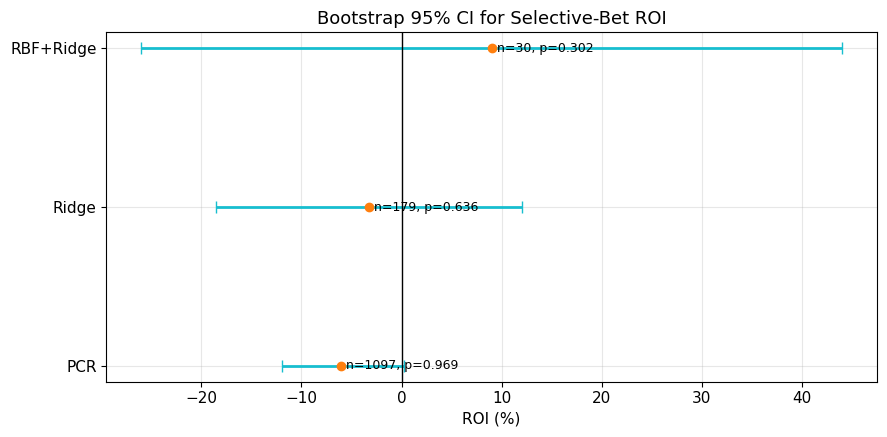

In [256]:
# Plot bootstrap confidence intervals
if boot_results:
    ci_rows = []
    for m, b in boot_results.items():
        ci_rows.append({
            'model': m,
            'roi': b['observed_roi'],
            'ci_lower': b['ci_lower'],
            'ci_upper': b['ci_upper'],
            'n_bets': b['n_bets'],
            'p_value': b['p_value'],
        })
    ci_df = pd.DataFrame(ci_rows).sort_values('roi')

    fig, ax = plt.subplots(figsize=(9, 4.5))
    ax.errorbar(ci_df['roi'], ci_df['model'],
xerr=[ci_df['roi'] - ci_df['ci_lower'], ci_df['ci_upper'] - ci_df['roi']],
fmt='o', color=COLORS['secondary'], ecolor=COLORS['highlight'], elinewidth=2, capsize=4)
    ax.axvline(0, color='black', lw=1)
    ax.set_xlabel('ROI (%)')
    ax.set_title('Bootstrap 95% CI for Selective-Bet ROI')
    for row in ci_df.itertuples():
        ax.text(row.roi + 0.5, row.model, f"n={row.n_bets}, p={row.p_value:.3f}", va='center', fontsize=9)
    plt.tight_layout()
    plt.savefig('Images/bootstrap_ci_models.png', dpi=150, bbox_inches='tight')
    plt.show()

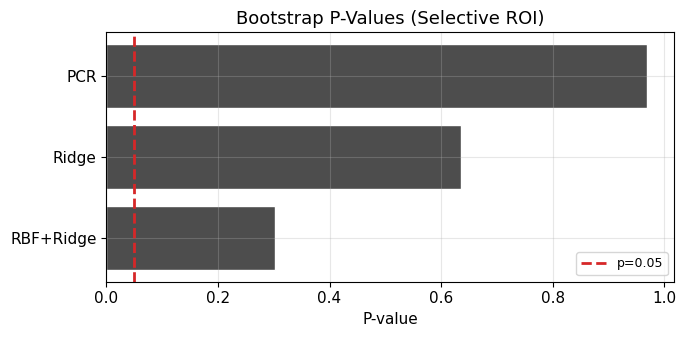

In [257]:
# Figure: P-values for focus models
if boot_results:
    pv_rows = []
    for m, b in boot_results.items():
        pv_rows.append({'model': m, 'p_value': b['p_value']})
    pv_df = pd.DataFrame(pv_rows).sort_values('p_value')

    fig, ax = plt.subplots(figsize=(7, 3.5))
    ax.barh(pv_df['model'], pv_df['p_value'], color=COLORS['neutral'], edgecolor='white')
    ax.axvline(0.05, color=COLORS['loss'], ls='--', lw=2, label='p=0.05')
    ax.set_title('Bootstrap P-Values (Selective ROI)')
    ax.set_xlabel('P-value')
    ax.legend(fontsize=9)
    plt.tight_layout()
    plt.savefig('Images/bootstrap_pvalues.png', dpi=150, bbox_inches='tight')
    plt.show()

**Observations:**
- IID and block bootstrap confidence intervals include zero, so none of the selective strategies are statistically significant.
- RBF+Ridge has the highest point estimate, but uncertainty remains wide.
- PCR remains an accuracy benchmark only; it does not deliver reliable selective ROI.
- The p-values stay above 0.05 across methods, so we cannot reject the null.

**Plain-language takeaway:** The data does not provide strong evidence that any model has a reliable edge. The apparent ROI pockets could still be luck in a small sample.

**Next step:** Summarize what these results imply and what we could change to try to reach profitability.

---
## Part 7: Recap and Path to Profit

**Recap (Parts 1-6):**
- Data coverage is strong after the API fill, with 2020 showing a COVID-driven dip.
- Features add signal beyond Vegas, but the market line remains the dominant predictor.
- No model beats break-even on all bets; selective betting creates a small ROI pocket for RBF+Ridge but lacks statistical significance.
- Focus set: Ridge (best model accuracy) and RBF+Ridge (best selective ROI pocket). PCR stays as an accuracy benchmark only.
- We use **RBF+Ridge** for bankroll sizing demos because it has the strongest selective-ROI pocket among the models.

**What might create a real edge next:**
- **Better inputs:** injuries, travel, rest quality, pace, and lineup continuity can shift totals quickly.
- **Market timing:** incorporate line movement and bet at open vs close to capture stale numbers.
- **Target shift:** predict total minus Vegas line (edge) instead of raw total to reduce noise.
- **Calibration:** map prediction gaps to calibrated win probabilities before sizing bets.
- **Regime awareness:** allow different thresholds or models for early season vs late season and playoffs.

**Why this matters for a new reader:** In efficient markets, small errors get priced in quickly. The most realistic path to profit is better data and better decision rules, not just a more complex algorithm.

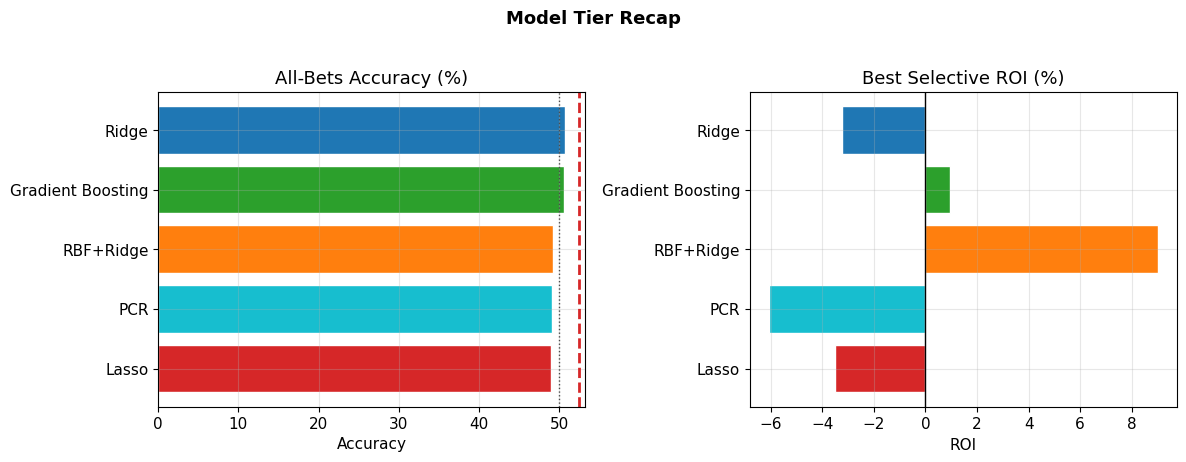

In [258]:
# Figure: Model tier recap (accuracy vs selective ROI)
summary_rows = []
for name in ['PCR', 'Ridge', 'RBF+Ridge', 'Lasso', 'Gradient Boosting']:
    if name in results_tuned['method'].values and name in threshold_results:
        acc = results_tuned[results_tuned['method'] == name]['accuracy'].values[0] * 100
        t = best_thresholds.get(name)
        roi = np.nan
        if t is not None:
            row = threshold_results[name][threshold_results[name]['threshold'] == t].iloc[0]
            roi = row['roi']
        summary_rows.append({'model': name, 'accuracy': acc, 'roi': roi})
summary_df = pd.DataFrame(summary_rows)

def tier_color(name):
    return MODEL_COLORS.get(name, COLORS['neutral'])

if not summary_df.empty:
    summary_df = summary_df.sort_values('accuracy', ascending=False).reset_index(drop=True)
    colors = [tier_color(m) for m in summary_df['model']]
    y = np.arange(len(summary_df))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

    ax = axes[0]
    ax.barh(y, summary_df['accuracy'], color=colors, edgecolor='white')
    ax.axvline(52.4, color=COLORS['breakeven'], ls='--', lw=2)
    ax.axvline(50, color=COLORS['neutral'], ls=':', lw=1)
    ax.set_yticks(y); ax.set_yticklabels(summary_df['model'])
    ax.set_title('All-Bets Accuracy (%)')
    ax.set_xlabel('Accuracy')
    ax.invert_yaxis()

    ax = axes[1]
    ax.barh(y, summary_df['roi'].fillna(0), color=colors, edgecolor='white')
    ax.axvline(0, color='black', lw=1)
    ax.set_yticks(y); ax.set_yticklabels(summary_df['model'])
    ax.set_title('Best Selective ROI (%)')
    ax.set_xlabel('ROI')
    ax.invert_yaxis()

    fig.suptitle('Model Tier Recap', fontsize=13, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.savefig('Images/model_tier_recap.png', dpi=150, bbox_inches='tight')
    plt.show()

**Observations:**
- The analysis to date finds small, unstable ROI pockets but no statistically significant edge.
- Ridge is the most stable linear model, while RBF+Ridge shows the strongest selective-ROI pocket among the models we keep. Gradient Boosting has a smaller pocket but is not stable enough to carry forward.
- The path forward is improved data, better calibration, and smarter timing rather than more complex models alone.

**Next step:** Test how bet sizing affects bankroll behavior when we scale bet size by confidence.

---
## Part 8: Improve Method (Confidence-Weighted Betting)

We focus on the strongest model from Part 5 (RBF+Ridge) and compare **bet sizing rules** while also testing **minimum-gap thresholds**.

**What bet sizing means:** Instead of betting the same amount every game, we bet more when the model is more confident and less (or zero) when it is not.

**Step-by-step logic for each game:**
1. Predict the total points using the trained model.
2. Compute the **gap** = |prediction - Vegas line|.
3. Estimate a win probability $p$ for the Over/Under direction using the gap and the model's historical error.
4. Apply a minimum-gap threshold (e.g., 0, 3, 5, 6). If the gap is smaller, we do not bet.
5. If we do bet, size the bet using one of the rules below.

**Why add thresholds back in?**
- Even with Kelly sizing, very small edges can be noise.
- We compare multiple gap cutoffs (for example, 0, 3, 5, 6 points) to see whether filtering improves results.

**Sizing rules compared:**
- Fixed fraction (1% / 2%)
- Kelly (cap 10%)
- Half Kelly (cap 10%)
- Kelly (cap 5%)
- Edge-linear (cap 5%)

**Kelly formula (for -110 odds):**
- Let $p$ be the model's estimated probability of winning the bet and $q = 1 - p$.
- Let $b$ be net odds per $1 risked ($b=0.909$ at -110).
- The Kelly fraction is $f^* = \frac{bp - q}{b}$.
- If $f^*$ is negative, the optimal action is to **not bet**.

**How the curves are built here:**
- We estimate $p$ for the bet direction using the prediction gap and residual volatility (assuming errors are roughly normal).
- We apply a minimum-gap threshold, then size bets with each rule.
- This lets us compare sizing rules **and** threshold filtering side-by-side.

**Implementation takeaway:** In this run, the best in-sample bankroll outcome comes from RBF+Ridge with threshold>6 using a capped Kelly or Half-Kelly rule. For real-world use, Half Kelly (cap 10%) with threshold>6 is a more conservative default than full Kelly, and Fixed 1% is the safest if you want minimal drawdowns.

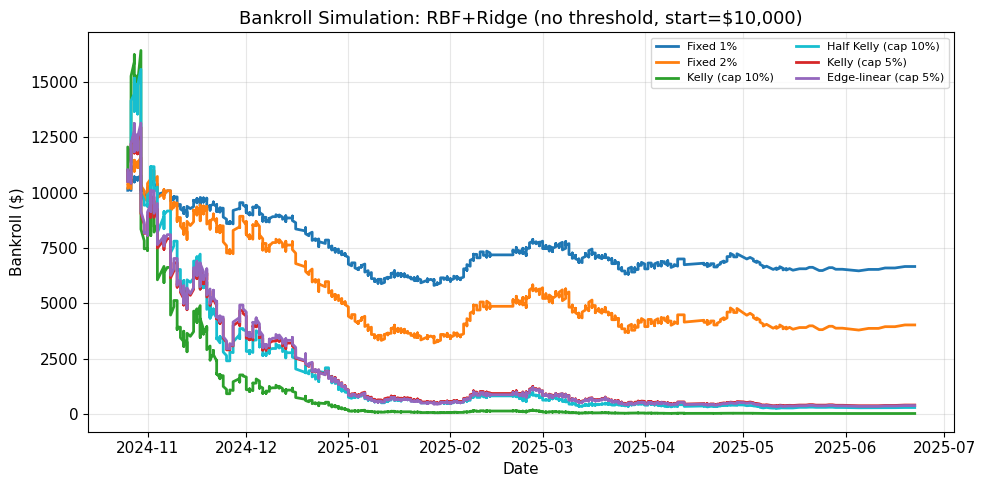

RBF+Ridge final bankrolls (threshold>0):
Fixed 1%                6657.457867
Fixed 2%                4018.787130
Kelly (cap 5%)           399.694691
Edge-linear (cap 5%)     376.928154
Half Kelly (cap 10%)     288.735608
Kelly (cap 10%)           18.300124



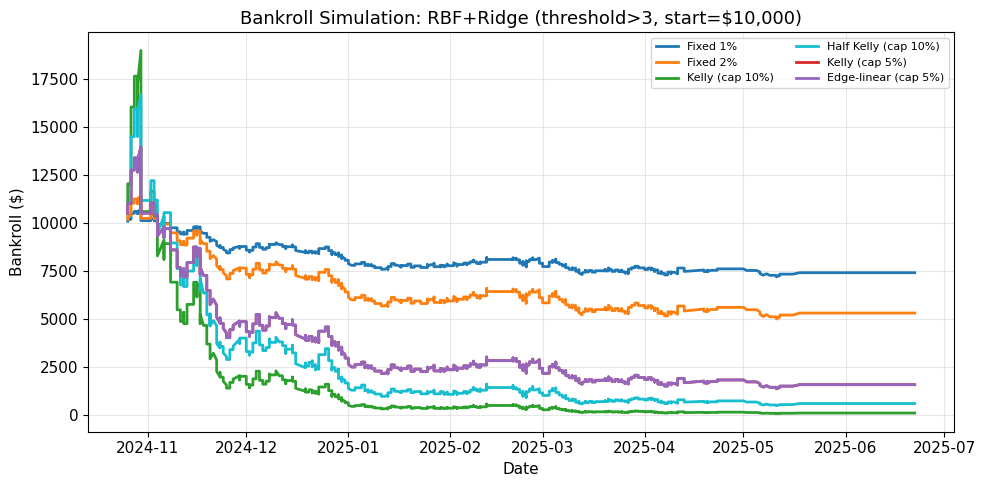

RBF+Ridge final bankrolls (threshold>3):
Fixed 1%                7421.430774
Fixed 2%                5320.852419
Kelly (cap 5%)          1591.207186
Edge-linear (cap 5%)    1591.207186
Half Kelly (cap 10%)     610.492144
Kelly (cap 10%)          115.062036



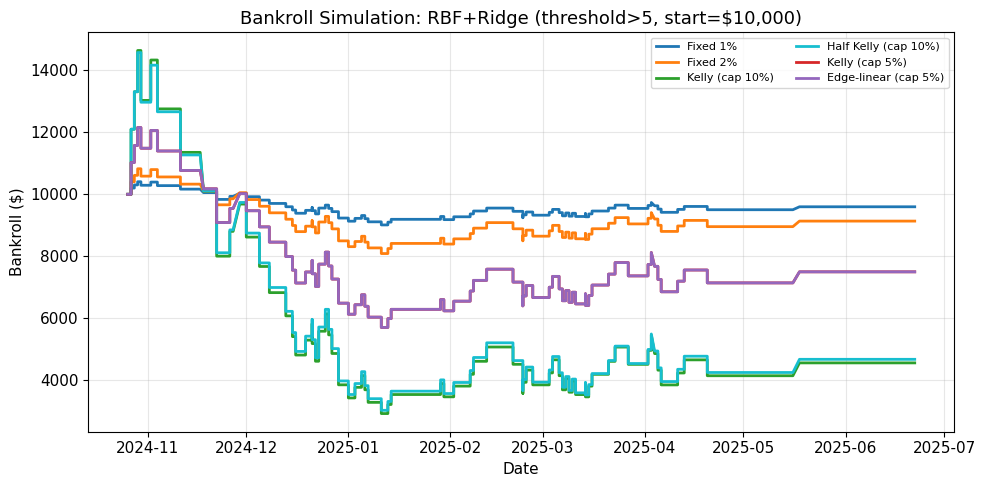

RBF+Ridge final bankrolls (threshold>5):
Fixed 1%                9597.400516
Fixed 2%                9135.745283
Kelly (cap 5%)          7498.613691
Edge-linear (cap 5%)    7498.613691
Half Kelly (cap 10%)    4675.335091
Kelly (cap 10%)         4559.944919



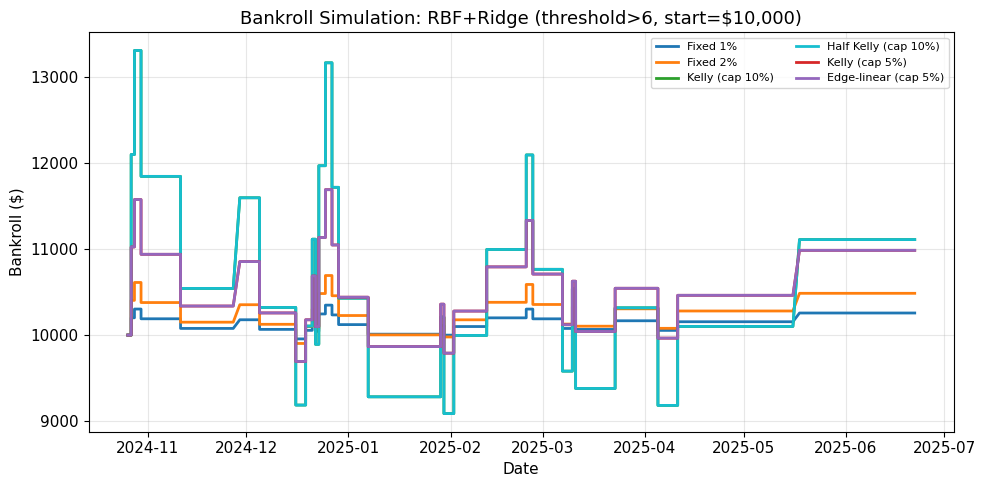

RBF+Ridge final bankrolls (threshold>6):
Kelly (cap 10%)         11110.810334
Half Kelly (cap 10%)    11110.810334
Kelly (cap 5%)          10985.797635
Edge-linear (cap 5%)    10985.797635
Fixed 2%                10485.956028
Fixed 1%                10256.876942



In [259]:
# Build confidence-weighted bankroll curves on the test set
from scipy.special import erf as sp_erf

def normal_cdf(x):
    return 0.5 * (1.0 + sp_erf(x / np.sqrt(2.0)))

def simulate_bankroll_methods(test_df, preds, vegas_line, threshold=0, start_bankroll=10000.0, odds=-110):
    lose_amt = abs(odds) / 100
    b = 1.0 / lose_amt  # net odds per 1 risked (e.g., 0.9091)
    p_break = 1.0 / (b + 1.0)
    df = test_df[['date', 'actual_total']].copy()
    df['vegas'] = np.array(vegas_line)
    df['pred'] = np.array(preds)
    df = df.sort_values('date').reset_index(drop=True)

    sigma = np.std(df['actual_total'] - df['pred'], ddof=1)
    if not np.isfinite(sigma) or sigma <= 0:
        sigma = 12.0

    pred = df['pred'].values
    vegas = df['vegas'].values
    actual = df['actual_total'].values
    gap = np.abs(pred - vegas)
    bet_over = pred > vegas
    p_over = 1.0 - normal_cdf((vegas - pred) / sigma)
    p_win = np.where(bet_over, p_over, 1.0 - p_over)
    kelly_raw = (p_win * (b + 1.0) - 1.0) / b
    kelly_raw = np.clip(kelly_raw, 0.0, None)
    edge = np.clip(p_win - p_break, 0.0, None)
    gap_mask = gap > threshold

    fracs = {
        'Fixed 1%': np.where((p_win > p_break) & gap_mask, 0.01, 0.0),
        'Fixed 2%': np.where((p_win > p_break) & gap_mask, 0.02, 0.0),
        'Kelly (cap 10%)': np.where(gap_mask, np.clip(kelly_raw, 0.0, 0.10), 0.0),
        'Half Kelly (cap 10%)': np.where(gap_mask, np.clip(0.5 * kelly_raw, 0.0, 0.10), 0.0),
        'Kelly (cap 5%)': np.where(gap_mask, np.clip(kelly_raw, 0.0, 0.05), 0.0),
        'Edge-linear (cap 5%)': np.where(gap_mask, np.clip(edge * 2.5, 0.0, 0.05), 0.0),
    }

    banks = {name: start_bankroll for name in fracs}
    rows = []
    for i in range(len(df)):
        win = (pred[i] > vegas[i]) == (actual[i] > vegas[i])
        row = {'date': df['date'].iat[i]}
        for name, frac in fracs.items():
            risk = banks[name] * frac[i]
            if risk > 0:
                banks[name] += risk if win else -risk * lose_amt
            row[name] = banks[name]
        rows.append(row)
    out = pd.DataFrame(rows)
    diagnostics = pd.DataFrame({
        'p_win': p_win,
        'kelly_raw': kelly_raw,
        'edge': edge,
        'p_break': p_break,
        'gap': gap,
        'gap_mask': gap_mask,
    })
    return out, diagnostics


BANKROLL_MODEL = 'RBF+Ridge'
BANKROLL_THRESHOLDS = [0, 3, 5, 6]
METHOD_COLORS = {
    'Fixed 1%': '#1F77B4',
    'Fixed 2%': '#FF7F0E',
    'Kelly (cap 10%)': '#2CA02C',
    'Half Kelly (cap 10%)': '#17BECF',
    'Kelly (cap 5%)': '#D62728',
    'Edge-linear (cap 5%)': '#9467BD',
}

if BANKROLL_MODEL in preds_tuned:
    bankroll_results = {}
    diagnostics_map = {}
    for t in BANKROLL_THRESHOLDS:
        sim, diag = simulate_bankroll_methods(test_df, preds_tuned[BANKROLL_MODEL], vegas_test, threshold=t)
        bankroll_results[t] = sim
        diagnostics_map[t] = diag

        fig, ax = plt.subplots(figsize=(10, 5))
        for method in METHOD_COLORS:
            ax.plot(sim['date'], sim[method], label=method, lw=2, color=METHOD_COLORS[method])
        title_t = f'threshold>{t}' if t > 0 else 'no threshold'
        ax.set_title(f'Bankroll Simulation: {BANKROLL_MODEL} ({title_t}, start=$10,000)')
        ax.set_xlabel('Date'); ax.set_ylabel('Bankroll ($)')
        ax.legend(ncol=2, fontsize=8)
        plt.tight_layout()
        plt.savefig(f'Images/bankroll_{BANKROLL_MODEL.lower().replace('+','plus')}_t{t}.png', dpi=150, bbox_inches='tight')
        plt.show()

        final_vals = sim.drop(columns=['date']).iloc[-1].sort_values(ascending=False)
        print(f"{BANKROLL_MODEL} final bankrolls (threshold>{t}):")
        print(final_vals.to_string())
        print()
else:
    print("Bankroll simulation skipped (missing model results).")

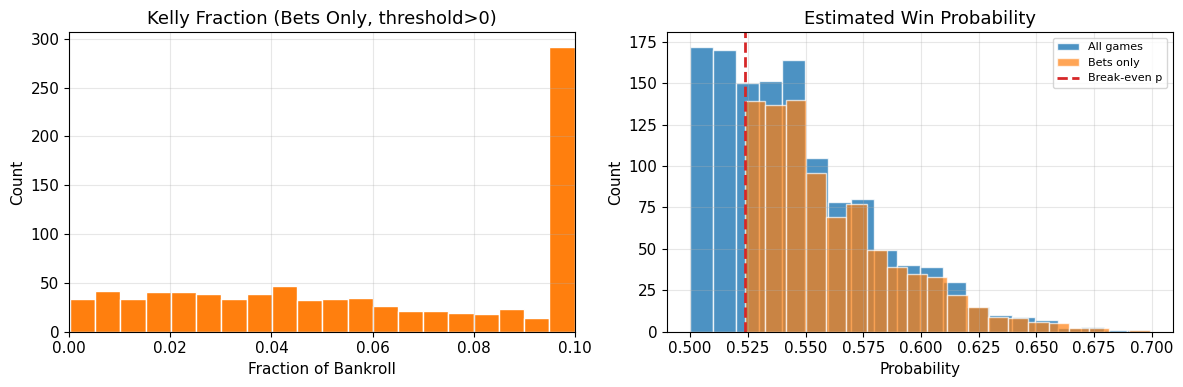

In [260]:
# Figure: Kelly and probability diagnostics (RBF+Ridge, choose first threshold with bets)
if 'diagnostics_map' in locals():
    diag_threshold = None
    for t in sorted(diagnostics_map.keys()):
        diag_t = diagnostics_map[t]
        mask_t = (diag_t['kelly_raw'] > 0) & (diag_t['gap_mask'])
        if mask_t.any():
            diag_threshold = t
            break
    if diag_threshold is None:
        print('Kelly diagnostics skipped (no Kelly-positive bets).')
    else:
        diag = diagnostics_map[diag_threshold]
        bet_mask = (diag['kelly_raw'] > 0) & (diag['gap_mask'])

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        ax = axes[0]
        ax.hist(diag.loc[bet_mask, 'kelly_raw'].clip(upper=0.10), bins=20,
                color=MODEL_COLORS.get(BANKROLL_MODEL, COLORS['secondary']), edgecolor='white')
        ax.set_title(f'Kelly Fraction (Bets Only, threshold>{diag_threshold})')
        ax.set_xlabel('Fraction of Bankroll'); ax.set_ylabel('Count')
        ax.set_xlim(0, 0.10)

        ax = axes[1]
        ax.hist(diag['p_win'], bins=20, color=COLORS['primary'], edgecolor='white', alpha=0.8, label='All games')
        ax.hist(diag.loc[bet_mask, 'p_win'], bins=20, color=COLORS['secondary'], edgecolor='white', alpha=0.7, label='Bets only')
        ax.axvline(diag['p_break'].iloc[0], color=COLORS['loss'], ls='--', lw=2, label='Break-even p')
        ax.set_title('Estimated Win Probability')
        ax.set_xlabel('Probability'); ax.set_ylabel('Count')
        ax.legend(fontsize=8)

        plt.tight_layout()
        plt.savefig('Images/kelly_diagnostics.png', dpi=150, bbox_inches='tight')
        plt.show()
else:
    print('Kelly diagnostics skipped (missing simulation outputs).')

**Observations:**
- Across threshold choices, fixed-fraction rules are steadier while Kelly-based rules are more volatile.
- Adding a gap threshold (for example, 5 or 6) reduces bet count and can improve outcomes if the small-edge bets are mostly noise.
- The probability histogram makes the bet filter explicit: only games above the break-even $p$ and above the gap threshold get nonzero stakes.
- Even with better sizing, profitability is not guaranteed when the underlying edge is weak.

**Best-performing method (this run):** RBF+Ridge with threshold>6 and a capped Kelly or Half-Kelly rule produces the highest ending bankroll. Fixed 1% with threshold>6 is the most conservative alternative.

**Real-world recommendation:** Use RBF+Ridge with threshold>6 and Half Kelly (cap 10%) if you are willing to accept moderate volatility. If you want maximum safety, use Fixed 1% with threshold>6 and monitor results weekly.

**Next step:** Choose a sizing rule and threshold that best match risk tolerance for the final report.

---
## Part 9: Alternative Data and Advanced Models (Plan Outline)

We will explore whether richer inputs or more flexible models could uncover a durable edge.
- Alternative data: injuries, lineup changes, travel distance, rest quality, pace, and betting market signals.
- More advanced models: tree ensembles, calibrated probability models, and time-aware architectures.
- Goal: test if better information or structure improves prediction quality beyond the Vegas line.

---
## Part 10: Real-World Implementation Constraints (Plan Outline)

We will discuss practical frictions that affect live deployment.
- Data latency and availability (how quickly inputs update).
- Line movement, price slippage, and limits.
- Risk controls, bet sizing caps, and exposure management.
- Compliance, transparency, and operational reliability.

---
## Part 11: 2025-26 Season / Bulls Tracker (Plan Outline)

We will outline a live demonstration for the presentation.
- Track a real team or season (e.g., Bulls) with weekly model updates.
- Show predictions vs Vegas, betting decisions, and realized outcomes.
- Focus on interpretability and process, not just profit.